============================================================================
# COMPARISONS of RESPONSES (analyzing the evaluation results)
============================================================================

Analysis Notebook

Metrics
---------------
- Semantic Similarity (Cosine)
- Entity Overlap (Jaccard Similarity Index)
- Reference Overlap (Jaccard Similarity Index)
- Numerical Instances Overlap (Jaccard Similarity Index)
- Number of % Mentioned Overlap (absolute difference)
- Flesch Reading Ease Score
- Medical Jargon Score ([from MedReadMe paper](https://huggingface.co/chaojiang06/medreadme_medical_sentence_readability_prediction_CWI))
- Response Length (# of words)
- Hedge Count (text matching)
- Evidence Direction Agreement (%)

All metrics compare positive vs negative (or more generically two paired) question responses.
Also, we compare metrics by the category of the questions, condition, year of review publication, etc.

## Setup and Helper Functions

In [101]:
import pandas as pd
from utils import load_json_file, load_csv_file, load_jsonl_file
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import json
import traceback
import warnings
warnings.filterwarnings('ignore')

class NumpyTypeEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.generic):
            return obj.item()
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)
    

sns.set_context("paper", font_scale=1.2)

plt.rcParams.update({
    'font.family': 'sans-serif',
    # 'font.sans-serif': ['Inter', 'Helvetica Neue', 'Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

sns.set_style("ticks")

In [102]:
model_names = [
    "gpt-5.1", "claude_4.5_sonnet", "api-llama3.3", "api-llama4",
    "qwen3-4B", "qwen3-30B",
    "huatuo-7B", "huatuo-8B"
]

# extra
# "huatuo-70B"

# Model name to display label mapping
MODEL_LABELS = {
    "gpt-5.1": "GPT 5.1",
    "claude_4.5_sonnet": "Claude Sonnet 4.5",
    "api-llama3.3": "Llama 3.3 70B",
    "api-llama4": "Llama 4 Maverick 17B",
    "qwen3-4B": "Qwen3 4B",
    "qwen3-30B": "Qwen3 30B",
    "huatuo-7B": "HuatuoGPT 7B",
    "huatuo-8B": "HuatuoGPT 8B",
    "huatuo-70B": "HuatuoGPT 70B",
}

MODEL_LABELS_NEWLINE = {
    "gpt-5.1": "GPT 5.1",
    "claude_4.5_sonnet": "Claude\nSonnet 4.5",
    "api-llama3.3": "Llama 3.3 70B",
    "api-llama4": "Llama 4\nMaverick 17B",
    "qwen3-4B": "Qwen3 4B",
    "qwen3-30B": "Qwen3 30B",
    "huatuo-7B": "HuatuoGPT 7B",
    "huatuo-8B": "HuatuoGPT 8B",
    "huatuo-70B": "HuatuoGPT 70B",
}

In [103]:
def load_analysis_results_for_model(model_name: str, data_type: str = "framing") -> list[dict]:
    if data_type == "framing":
        file_path = f"outputs/evaluation/{model_name}_eval_results.json"
    elif data_type == "baseline":
        file_path = f"outputs/paraphrased_baseline_evaluation/{model_name}_eval_results.json"
    elif data_type == "simplified_framing":
        file_path = f"outputs/evaluation/{model_name}_eval_results_simplified.json"
    elif data_type == "simplified_baseline":
        file_path = f"outputs/paraphrased_baseline_evaluation/{model_name}_eval_results_simplified.json"

    try:
        data = load_json_file(file_path)
        print(f"Number of entries in {file_path}: {len(data)}")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        data = []

    return data

def load_year_mapping() -> dict:
    """Load a mapping from ReviewID to publication year from cochrane_review_data.jsonl."""
    data = load_jsonl_file("../data/cochrane_review_data.jsonl")
    year_map = {}
    for entry in data:
        year_map[entry["ReviewID"]] = entry["Year"]
    return year_map

def load_num_sources_mapping() -> dict:
    """Load a mapping from ReviewID to number of sources from cochrane_review_data.jsonl."""
    data = load_jsonl_file("../data/cochrane_review_data.jsonl")
    num_sources_map = {}
    for entry in data:
        num_sources_map[entry["ReviewID"]] = entry["NumInputs"]
    return num_sources_map

def load_format_condition_category_data() -> dict:
    condition_category_data = load_csv_file("../data/cochrane_review_categorized_conditions.csv")
    condition_category_mapping = {row["ReviewID"]: row["category"] for row in condition_category_data}
    return condition_category_mapping

def get_jaccard_similarity(set1: set, set2: set) -> float:
    """Helper function to calculate jaccard similarity index between two sets"""
    if not set1 and not set2:
        return 0.0
    common_elements = set1.intersection(set2)
    total_unique_elements = set1.union(set2)
    jaccard_similarity = len(common_elements) / len(total_unique_elements) if total_unique_elements else 0.0
    return jaccard_similarity

def format_results_for_analysis(data: list[dict]) -> pd.DataFrame:
    if not data:
        print("No data to format.")
        return pd.DataFrame()  # Return an empty DataFrame if there's no data
    
    year_mapping = load_year_mapping()
    num_sources_mapping = load_num_sources_mapping()
    condition_category_mapping = load_format_condition_category_data()
    formatted_data = []
    for key, value in data.items():
        review_id, question_category = key.split('_')
        question_category = question_category if question_category != "doctor" else "second_opinion"
        comp = value['comparison']
        first_response_metrics = value['first_response_metrics']
        second_response_metrics = value['second_response_metrics']

        first_response_references = set(first_response_metrics['unique_references'])
        second_response_references = set(second_response_metrics['unique_references'])
        jsi_common_references = get_jaccard_similarity(first_response_references, second_response_references)

        first_response_numerical_instances = set(first_response_metrics['numerical_instances'])
        second_response_numerical_instances = set(second_response_metrics['numerical_instances'])
        jsi_common_numerical_instances = get_jaccard_similarity(first_response_numerical_instances, second_response_numerical_instances)

        first_response_num_percentage_symbol_instances = first_response_metrics['num_percentage_symbol_instances']
        second_response_num_percentage_symbol_instances = second_response_metrics['num_percentage_symbol_instances']
        num_percentage_symbol_diff = abs(first_response_num_percentage_symbol_instances - second_response_num_percentage_symbol_instances)
        
        formatted_data.append({
            'full_id': key,
            'review_id': review_id,
            'year': int(year_mapping[review_id]),
            'num_sources': int(num_sources_mapping[review_id]),
            'category': question_category,
            'condition_category': condition_category_mapping[review_id],
            'cosine_similarity': comp['cosine_similarity'],
            'entity_overlap': comp['entity_jaccard_similarity'],
            'reference_overlap': jsi_common_references,
            'numerical_instances_overlap': jsi_common_numerical_instances,
            'percentage_symbol_instances_diff': num_percentage_symbol_diff,
            'first_response_hedges_text_count': first_response_metrics['hedges_text_match']['count'],
            'first_response_flesch_reading_ease': first_response_metrics['flesch_reading_ease'],
            'first_response_medical_jargon_score': first_response_metrics['medical_jargon_score'],
            'first_response_length': first_response_metrics['length_words'],
            'first_response_evidence_direction': first_response_metrics['evidence_direction'] if 'evidence_direction' in first_response_metrics else None,
            'second_response_flesch_reading_ease': second_response_metrics['flesch_reading_ease'],
            'second_response_medical_jargon_score': second_response_metrics['medical_jargon_score'],
            'second_response_length': second_response_metrics['length_words'],
            'second_response_hedges_text_count': second_response_metrics['hedges_text_match']['count'],
            'second_response_evidence_direction': second_response_metrics['evidence_direction'] if 'evidence_direction' in second_response_metrics else None
        })

    df = pd.DataFrame(formatted_data)
    return df

In [104]:
def preprocess_evidence_direction(value):
    """Preprocess evidence direction so 'same' and 'no difference' are treated as equivalent."""
    if value in ("same", "no difference"):
        return "same"
    return value

def calculate_evidence_agreement(df: pd.DataFrame) -> dict:
    """
    Base helper: compute evidence direction agreement on a given dataframe.
    'same' and 'no difference' are treated as equivalent.

    Args:
        df: Dataframe (can be pre-filtered)

    Returns:
        dict with keys [total, agreements, agreement_pct]
    """
    valid_mask = ~(df["first_response_evidence_direction"].isna() & df["second_response_evidence_direction"].isna())
    df_valid = df[valid_mask].copy()
    total = len(df_valid)

    first_processed = df_valid["first_response_evidence_direction"].map(
        lambda x: preprocess_evidence_direction(x)
    )
    second_processed = df_valid["second_response_evidence_direction"].map(
        lambda x: preprocess_evidence_direction(x)
    )

    agreements = (
        (first_processed == second_processed)
        & first_processed.notna()
    ).sum()
    agreement_pct = (agreements / total * 100) if total > 0 else 0
    return {"total": total, "agreements": int(agreements), "agreement_pct": round(agreement_pct, 2)}

def calculate_multiturn_agreement(data: pd.DataFrame) -> dict:
    """
    Compute evidence direction agreement for only multiturn question category rows
    (includes multiturn0, multiturn1, multiturn2, multiturn3, etc.).

    Args:
        data: Dataframe

    Returns:
        dict with keys [total, agreements, agreement_pct]
    """
    multiturn_df = data[data["category"].str.startswith("multiturn")]
    return calculate_evidence_agreement(multiturn_df)


def calculate_singleturn_agreement(data: pd.DataFrame) -> dict:
    """
    Compute evidence direction agreement for single-turn question category rows.

    Args:
        data: Dataframe

    Returns:
        dict with keys [total, agreements, agreement_pct]
    """
    singleturn_df = data[~data["category"].str.startswith("multiturn")]
    return calculate_evidence_agreement(singleturn_df)

def calculate_question_category_agreement(data: pd.DataFrame) -> dict:
    """
    Compute evidence direction agreement grouped by question category.

    Args:
        data: Dataframe (can be pre-filtered, e.g. multiturn or non-multiturn rows)

    Returns:
        dict mapping question_category -> agreement_pct
    """
    result = {}
    for q_category, group in data.groupby("category"):
        result[q_category] = calculate_evidence_agreement(group)['agreement_pct']
    return result


def calculate_condition_category_agreement(data: pd.DataFrame) -> dict:
    """
    Compute evidence direction agreement grouped by condition category.

    Args:
        data: Dataframe (can be pre-filtered, e.g. multiturn or non-multiturn rows)

    Returns:
        dict mapping condition_category -> agreement_pct
    """
    result = {}
    for condition, group in data.groupby("condition_category"):
        result[condition] = calculate_evidence_agreement(group)['agreement_pct']
    return result

def calculate_agreement_by_year(data: pd.DataFrame) -> dict:
    """
    Compute evidence direction agreement grouped by publication year.

    Args:
        data: Dataframe

    Returns:
        dict mapping year -> agreement_pct
    """
    result = {}
    for year, group in data.groupby("year"):
        result[year] = calculate_evidence_agreement(group)['agreement_pct']
    return result

def calculate_agreement_by_num_sources(data: pd.DataFrame) -> dict:
    """
    Compute evidence direction agreement grouped by number of sources.

    Args:
        data: Dataframe

    Returns:
        dict mapping num_sources -> agreement_pct
    """
    result = {}
    for num_sources, group in data.groupby("num_sources"):
        result[num_sources] = calculate_evidence_agreement(group)['agreement_pct']
    return result

In [105]:
def calculate_global_stats(df: pd.DataFrame) -> dict:
    if df.empty:
        print("DataFrame is empty. Cannot calculate global stats.")
        return {}
    # Get evidence agreement for all rows
    overall_agreement = calculate_evidence_agreement(df)

    # Get evidence agreement for single-turn question category rows
    singleturn_agreement = calculate_singleturn_agreement(df)

    # Get evidence agreement for only multiturn question category rows
    multiturn_agreement = calculate_multiturn_agreement(df)

    # Get evidence agreement for each question category
    question_category_agreement = calculate_question_category_agreement(df)

    # Get evidence agreement for each condition category - single-turn question category rows
    singleturn_df = df[~df["category"].str.startswith("multiturn")]
    condition_agreement_singleturn = calculate_condition_category_agreement(singleturn_df)

    # Get evidence agreement for each condition category - only multiturn question category rows
    multiturn_df = df[df["category"].str.startswith("multiturn")]
    condition_agreement_multiturn = calculate_condition_category_agreement(multiturn_df)

    # Get evidence agreement by publication year 
    overall_year_level_stats = calculate_agreement_by_year(df)

    # Get evidence agreement by number of sources
    overall_num_sources_stats = calculate_agreement_by_num_sources(df)

    global_stats = {
        'mean_similarity': round(df['cosine_similarity'].mean(), 2),
        'mean_entity_overlap': round(df['entity_overlap'].mean(), 2),
        'mean_reference_overlap': round(df['reference_overlap'].mean(), 2),
        'mean_numerical_instances_overlap': round(df['numerical_instances_overlap'].mean(), 2),
        'mean_percentage_symbol_instances_diff': round(df['percentage_symbol_instances_diff'].mean(), 2),
        'flesch_reading_ease': {
            'first_mean': round(df['first_response_flesch_reading_ease'].mean(), 3),
            'second_mean': round(df['second_response_flesch_reading_ease'].mean(), 3),
            'difference': round(df['first_response_flesch_reading_ease'].mean() - df['second_response_flesch_reading_ease'].mean(), 3)
        },
        'medical_jargon_score': {
            'first_mean': round(df['first_response_medical_jargon_score'].mean(), 3),
            'second_mean': round(df['second_response_medical_jargon_score'].mean(), 3),
            'difference': round(df['first_response_medical_jargon_score'].mean() - df['second_response_medical_jargon_score'].mean(), 3)
        },
        'length': {
            'first_mean': round(df['first_response_length'].mean(), 3),
            'second_mean': round(df['second_response_length'].mean(), 3),
            'difference': round(df['first_response_length'].mean() - df['second_response_length'].mean(), 3)
        },
        'hedges_text_count': {
            'first_mean': round(df['first_response_hedges_text_count'].mean(), 3),
            'second_mean': round(df['second_response_hedges_text_count'].mean(), 3),
            'difference': round(df['first_response_hedges_text_count'].mean() - df['second_response_hedges_text_count'].mean(), 3)
        },
        'evidence_direction': {
            'overall_agreement_pct': overall_agreement['agreement_pct'],
            'singleturn_agreement': singleturn_agreement['agreement_pct'],
            'multiturn_agreement': multiturn_agreement['agreement_pct'],
            'question_category_agreement': question_category_agreement,
            'condition_category_agreement_singleturn': condition_agreement_singleturn,
            'condition_category_agreement_multiturn': condition_agreement_multiturn,
            'overall_year_level_agreement_pct': overall_year_level_stats,
            'overall_num_sources_agreement_pct': overall_num_sources_stats
        }
    }
    return global_stats

In [106]:
def load_global_stats_for_all_models(model_names: list[str]) -> dict[str, dict]:
    """
    Load and calculate global statistics for all models.
    
    Args:
        model_names: List of model names to process
        
    Returns:
        Dictionary mapping model names to their global statistics
    """
    all_model_stats = {}
    
    for model_name in model_names:
        try:
            # Load data for this model
            framing_data = load_analysis_results_for_model(model_name, data_type="framing")
            baseline_data = load_analysis_results_for_model(model_name, data_type="baseline")
            simplified_framing_data = load_analysis_results_for_model(model_name, data_type="simplified_framing")
            simplified_baseline_data = load_analysis_results_for_model(model_name, data_type="simplified_baseline")

            # Format results
            df1 = format_results_for_analysis(framing_data)
            df2 = format_results_for_analysis(baseline_data)
            df3 = format_results_for_analysis(simplified_framing_data)
            df4 = format_results_for_analysis(simplified_baseline_data)

            # save formatted data for later use (in json)
            df1.to_json(f"outputs/analysis_paraphrased_baseline/{model_name}_framing.json", orient="records", indent=4)
            df2.to_json(f"outputs/analysis_paraphrased_baseline/{model_name}_baseline.json", orient="records", indent=4)
            df3.to_json(f"outputs/analysis_paraphrased_baseline/{model_name}_simplified_framing.json", orient="records", indent=4)
            df4.to_json(f"outputs/analysis_paraphrased_baseline/{model_name}_simplified_baseline.json", orient="records", indent=4)

            # Calculate global stats
            stats1 = calculate_global_stats(df1)
            stats2 = calculate_global_stats(df2)
            stats3 = calculate_global_stats(df3)
            stats4 = calculate_global_stats(df4)
            
            all_model_stats[model_name] = {
                "extracted_framing": stats1,
                "extracted_baseline": stats2,
                "simplified_framing": stats3,
                "simplified_baseline": stats4
            }
            print(f"✓ Loaded stats for {model_name}")

            # Save to JSON for later use
            with open(f"outputs/analysis_paraphrased_baseline/data/global_stats.json", "w") as f:
                json.dump(all_model_stats, f, indent=4, cls=NumpyTypeEncoder)
            
        except Exception as e:
            print(f"✗ Error loading {model_name}: {str(e)}")
            traceback.print_exc()
            continue
    
    return all_model_stats

In [107]:
def prepare_comparison_dataframe(all_model_stats: dict[str, dict]) -> pd.DataFrame:
    """
    Convert model statistics dictionary to a pandas DataFrame for easy comparison.
    
    Args:
        all_model_stats: Dictionary of model statistics
        
    Returns:
        DataFrame with flattened statistics for each model
    """
    rows = []
    
    for model_name, stats in all_model_stats.items():
        row = {
            'model': MODEL_LABELS.get(model_name, model_name),
            'model_custom': MODEL_LABELS_NEWLINE.get(model_name, model_name),
            'extracted_framing_mean_similarity': stats['extracted_framing']['mean_similarity'],
            'extracted_baseline_mean_similarity': stats['extracted_baseline']['mean_similarity'] if stats['extracted_baseline'] else None,
            'extracted_framing_mean_entity_overlap': stats['extracted_framing']['mean_entity_overlap'],
            'extracted_baseline_mean_entity_overlap': stats['extracted_baseline']['mean_entity_overlap'] if stats['extracted_baseline'] else None,
            'extracted_framing_mean_reference_overlap': stats['extracted_framing']['mean_reference_overlap'],
            'extracted_baseline_mean_reference_overlap': stats['extracted_baseline']['mean_reference_overlap'] if stats['extracted_baseline'] else None,
            'extracted_framing_mean_numerical_instances_overlap': stats['extracted_framing']['mean_numerical_instances_overlap'],
            'extracted_baseline_mean_numerical_instances_overlap': stats['extracted_baseline']['mean_numerical_instances_overlap'] if stats['extracted_baseline'] else None,
            'extracted_framing_mean_percentage_symbol_instances_diff': stats['extracted_framing']['mean_percentage_symbol_instances_diff'],
            'extracted_baseline_mean_percentage_symbol_instances_diff': stats['extracted_baseline']['mean_percentage_symbol_instances_diff'] if stats['extracted_baseline'] else None,
            'extracted_framing_flesch_first_mean': stats['extracted_framing']['flesch_reading_ease']['first_mean'],
            'extracted_baseline_flesch_first_mean': stats['extracted_baseline']['flesch_reading_ease']['first_mean'] if stats['extracted_baseline'] else None,
            'extracted_framing_flesch_second_mean': stats['extracted_framing']['flesch_reading_ease']['second_mean'],
            'extracted_baseline_flesch_second_mean': stats['extracted_baseline']['flesch_reading_ease']['second_mean'] if stats['extracted_baseline'] else None,
            'extracted_framing_flesch_difference': stats['extracted_framing']['flesch_reading_ease']['difference'],
            'extracted_baseline_flesch_difference': stats['extracted_baseline']['flesch_reading_ease']['difference'] if stats['extracted_baseline'] else None,
            'extracted_framing_jargon_first_mean': stats['extracted_framing']['medical_jargon_score']['first_mean'],
            'extracted_baseline_jargon_first_mean': stats['extracted_baseline']['medical_jargon_score']['first_mean'] if stats['extracted_baseline'] else None,
            'extracted_framing_jargon_second_mean': stats['extracted_framing']['medical_jargon_score']['second_mean'],
            'extracted_baseline_jargon_second_mean': stats['extracted_baseline']['medical_jargon_score']['second_mean'] if stats['extracted_baseline'] else None,
            'extracted_framing_jargon_difference': stats['extracted_framing']['medical_jargon_score']['difference'],
            'extracted_baseline_jargon_difference': stats['extracted_baseline']['medical_jargon_score']['difference'] if stats['extracted_baseline'] else None,
            'extracted_framing_length_first_mean': stats['extracted_framing']['length']['first_mean'],
            'extracted_baseline_length_first_mean': stats['extracted_baseline']['length']['first_mean'] if stats['extracted_baseline'] else None,
            'extracted_framing_length_second_mean': stats['extracted_framing']['length']['second_mean'],
            'extracted_baseline_length_second_mean': stats['extracted_baseline']['length']['second_mean'] if stats['extracted_baseline'] else None,
            'extracted_framing_length_difference': stats['extracted_framing']['length']['difference'],
            'extracted_baseline_length_difference': stats['extracted_baseline']['length']['difference'] if stats['extracted_baseline'] else None,
            'extracted_framing_hedges_first_mean': stats['extracted_framing']['hedges_text_count']['first_mean'],
            'extracted_baseline_hedges_first_mean': stats['extracted_baseline']['hedges_text_count']['first_mean'] if stats['extracted_baseline'] else None,
            'extracted_framing_hedges_second_mean': stats['extracted_framing']['hedges_text_count']['second_mean'],
            'extracted_baseline_hedges_second_mean': stats['extracted_baseline']['hedges_text_count']['second_mean'] if stats['extracted_baseline'] else None,
            'extracted_framing_hedges_difference': stats['extracted_framing']['hedges_text_count']['difference'],
            'extracted_baseline_hedges_difference': stats['extracted_baseline']['hedges_text_count']['difference'] if stats['extracted_baseline'] else None,
            'extracted_framing_overall_agreement_pct': stats['extracted_framing']['evidence_direction']['overall_agreement_pct'],
            'extracted_baseline_overall_agreement_pct': stats['extracted_baseline']['evidence_direction']['overall_agreement_pct'] if stats['extracted_baseline'] else None,
            'extracted_framing_singleturn_agreement': stats['extracted_framing']['evidence_direction']['singleturn_agreement'],
            'extracted_baseline_singleturn_agreement': stats['extracted_baseline']['evidence_direction']['singleturn_agreement'] if stats['extracted_baseline'] else None,
            'extracted_framing_multiturn_agreement': stats['extracted_framing']['evidence_direction']['multiturn_agreement'],
            'extracted_baseline_multiturn_agreement': stats['extracted_baseline']['evidence_direction']['multiturn_agreement'] if stats['extracted_baseline'] else None,
            'extracted_framing_question_category_agreement': json.dumps(stats['extracted_framing']['evidence_direction']['question_category_agreement']),
            'extracted_baseline_question_category_agreement': json.dumps(stats['extracted_baseline']['evidence_direction']['question_category_agreement']) if stats['extracted_baseline'] else None,
            'extracted_framing_condition_category_agreement_singleturn': json.dumps(stats['extracted_framing']['evidence_direction']['condition_category_agreement_singleturn']),
            'extracted_baseline_condition_category_agreement_singleturn': json.dumps(stats['extracted_baseline']['evidence_direction']['condition_category_agreement_singleturn']) if stats['extracted_baseline'] else None,
            'extracted_framing_condition_category_agreement_multiturn': json.dumps(stats['extracted_framing']['evidence_direction']['condition_category_agreement_multiturn']),
            'extracted_baseline_condition_category_agreement_multiturn': json.dumps(stats['extracted_baseline']['evidence_direction']['condition_category_agreement_multiturn']) if stats['extracted_baseline'] else None,
            'extracted_framing_overall_year_level_agreement_pct': json.dumps(stats['extracted_framing']['evidence_direction']['overall_year_level_agreement_pct']),
            'extracted_baseline_overall_year_level_agreement_pct': json.dumps(stats['extracted_baseline']['evidence_direction']['overall_year_level_agreement_pct']) if stats['extracted_baseline'] else None,
            'extracted_framing_overall_num_sources_agreement_pct': json.dumps(stats['extracted_framing']['evidence_direction']['overall_num_sources_agreement_pct']),
            'extracted_baseline_overall_num_sources_agreement_pct': json.dumps(stats['extracted_baseline']['evidence_direction']['overall_num_sources_agreement_pct']) if stats['extracted_baseline'] else None,
            'simplified_framing_mean_similarity': stats['simplified_framing']['mean_similarity'],
            'simplified_baseline_mean_similarity': stats['simplified_baseline']['mean_similarity'] if stats['simplified_baseline'] else None,
            'simplified_framing_mean_entity_overlap': stats['simplified_framing']['mean_entity_overlap'],
            'simplified_baseline_mean_entity_overlap': stats['simplified_baseline']['mean_entity_overlap'] if stats['simplified_baseline'] else None,
            'simplified_framing_mean_reference_overlap': stats['simplified_framing']['mean_reference_overlap'],
            'simplified_baseline_mean_reference_overlap': stats['simplified_baseline']['mean_reference_overlap'] if stats['simplified_baseline'] else None,
            'simplified_framing_mean_numerical_instances_overlap': stats['simplified_framing']['mean_numerical_instances_overlap'],
            'simplified_baseline_mean_numerical_instances_overlap': stats['simplified_baseline']['mean_numerical_instances_overlap'] if stats['simplified_baseline'] else None,
            'simplified_framing_mean_percentage_symbol_instances_diff': stats['simplified_framing']['mean_percentage_symbol_instances_diff'],
            'simplified_baseline_mean_percentage_symbol_instances_diff': stats['simplified_baseline']['mean_percentage_symbol_instances_diff'] if stats['simplified_baseline'] else None,
            'simplified_framing_flesch_first_mean': stats['simplified_framing']['flesch_reading_ease']['first_mean'],
            'simplified_baseline_flesch_first_mean': stats['simplified_baseline']['flesch_reading_ease']['first_mean'] if stats['simplified_baseline'] else None,
            'simplified_framing_flesch_second_mean': stats['simplified_framing']['flesch_reading_ease']['second_mean'],
            'simplified_baseline_flesch_second_mean': stats['simplified_baseline']['flesch_reading_ease']['second_mean'] if stats['simplified_baseline'] else None,
            'simplified_framing_flesch_difference': stats['simplified_framing']['flesch_reading_ease']['difference'],
            'simplified_baseline_flesch_difference': stats['simplified_baseline']['flesch_reading_ease']['difference'] if stats['simplified_baseline'] else None,
            'simplified_framing_jargon_first_mean': stats['simplified_framing']['medical_jargon_score']['first_mean'],
            'simplified_baseline_jargon_first_mean': stats['simplified_baseline']['medical_jargon_score']['first_mean'] if stats['simplified_baseline'] else None,
            'simplified_framing_jargon_second_mean': stats['simplified_framing']['medical_jargon_score']['second_mean'],
            'simplified_baseline_jargon_second_mean': stats['simplified_baseline']['medical_jargon_score']['second_mean'] if stats['simplified_baseline'] else None,
            'simplified_framing_jargon_difference': stats['simplified_framing']['medical_jargon_score']['difference'],
            'simplified_baseline_jargon_difference': stats['simplified_baseline']['medical_jargon_score']['difference'] if stats['simplified_baseline'] else None,
            'simplified_framing_length_first_mean': stats['simplified_framing']['length']['first_mean'],
            'simplified_baseline_length_first_mean': stats['simplified_baseline']['length']['first_mean'] if stats['simplified_baseline'] else None,
            'simplified_framing_length_second_mean': stats['simplified_framing']['length']['second_mean'],
            'simplified_baseline_length_second_mean': stats['simplified_baseline']['length']['second_mean'] if stats['simplified_baseline'] else None,
            'simplified_framing_length_difference': stats['simplified_framing']['length']['difference'],
            'simplified_baseline_length_difference': stats['simplified_baseline']['length']['difference'] if stats['simplified_baseline'] else None,
            'simplified_framing_hedges_first_mean': stats['simplified_framing']['hedges_text_count']['first_mean'],
            'simplified_baseline_hedges_first_mean': stats['simplified_baseline']['hedges_text_count']['first_mean'] if stats['simplified_baseline'] else None,
            'simplified_framing_hedges_second_mean': stats['simplified_framing']['hedges_text_count']['second_mean'],
            'simplified_baseline_hedges_second_mean': stats['simplified_baseline']['hedges_text_count']['second_mean'] if stats['simplified_baseline'] else None,
            'simplified_framing_hedges_difference': stats['simplified_framing']['hedges_text_count']['difference'],
            'simplified_baseline_hedges_difference': stats['simplified_baseline']['hedges_text_count']['difference'] if stats['simplified_baseline'] else None,
            'simplified_framing_overall_agreement_pct': stats['simplified_framing']['evidence_direction']['overall_agreement_pct'],
            'simplified_baseline_overall_agreement_pct': stats['simplified_baseline']['evidence_direction']['overall_agreement_pct'] if stats['simplified_baseline'] else None,
            'simplified_framing_singleturn_agreement': stats['simplified_framing']['evidence_direction']['singleturn_agreement'],
            'simplified_baseline_singleturn_agreement': stats['simplified_baseline']['evidence_direction']['singleturn_agreement'] if stats['simplified_baseline'] else None,
            'simplified_framing_multiturn_agreement': stats['simplified_framing']['evidence_direction']['multiturn_agreement'],
            'simplified_baseline_multiturn_agreement': stats['simplified_baseline']['evidence_direction']['multiturn_agreement'] if stats['simplified_baseline'] else None,
            'simplified_framing_question_category_agreement': json.dumps(stats['simplified_framing']['evidence_direction']['question_category_agreement']),
            'simplified_baseline_question_category_agreement': json.dumps(stats['simplified_baseline']['evidence_direction']['question_category_agreement']) if stats['simplified_baseline'] else None,
            'simplified_framing_condition_category_agreement_singleturn': json.dumps(stats['simplified_framing']['evidence_direction']['condition_category_agreement_singleturn']),
            'simplified_baseline_condition_category_agreement_singleturn': json.dumps(stats['simplified_baseline']['evidence_direction']['condition_category_agreement_singleturn']) if stats['simplified_baseline'] else None,
            'simplified_framing_condition_category_agreement_multiturn': json.dumps(stats['simplified_framing']['evidence_direction']['condition_category_agreement_multiturn']),
            'simplified_baseline_condition_category_agreement_multiturn': json.dumps(stats['simplified_baseline']['evidence_direction']['condition_category_agreement_multiturn']) if stats['simplified_baseline'] else None,
            'simplified_framing_overall_year_level_agreement_pct': json.dumps(stats['simplified_framing']['evidence_direction']['overall_year_level_agreement_pct']),
            'simplified_baseline_overall_year_level_agreement_pct': json.dumps(stats['simplified_baseline']['evidence_direction']['overall_year_level_agreement_pct']) if stats['simplified_baseline'] else None,
            'simplified_framing_overall_num_sources_agreement_pct': json.dumps(stats['simplified_framing']['evidence_direction']['overall_num_sources_agreement_pct']),
            'simplified_baseline_overall_num_sources_agreement_pct': json.dumps(stats['simplified_baseline']['evidence_direction']['overall_num_sources_agreement_pct']) if stats['simplified_baseline'] else None
        }
        rows.append(row)
    
    df = pd.DataFrame(rows)
    # Sort alphabetically by model name for consistent ordering
    df = df.sort_values(by='model', key=lambda x: x.str.lower().str[0]).reset_index(drop=True)
    return df

## Code for Plots/Data Visualizations

In [108]:
def plot_similarity_metrics_heatmap(df: pd.DataFrame, version: str = "extracted", figsize=(8, 4)):
    """
    Heatmap showing the difference (framing - baseline) for similarity/overlap metrics
    per model. Positive values mean framing > baseline, negative means framing < baseline.
    Args:
        df: DataFrame from prepare_comparison_dataframe
        version: "extracted" or "simplified" to specify which set of columns to use
        figsize: Figure size tuple
    """
    metrics = [
        ('mean_similarity', 'Cosine\nSimilarity'),
        ('mean_entity_overlap', 'Entity\nOverlap'),
        ('mean_reference_overlap', 'Reference\nOverlap'),
        ('mean_numerical_instances_overlap', 'Numerical\nOverlap')
    ]
    metric_keys = [k for k, _ in metrics]
    metric_labels = [lbl for _, lbl in metrics]
    models = df['model'].tolist()

    framing_data = df[[f'{version}_framing_{k}' for k in metric_keys]].values.astype(float)
    baseline_data = df[[f'{version}_baseline_{k}' for k in metric_keys]].values.astype(float)

    diff_data = framing_data - baseline_data

    # Symmetric color scale centered at 0
    abs_max = np.nanmax(np.abs(diff_data))
    if abs_max == 0:
        abs_max = 1.0

    # Create the custom colormap
    colors = ["#DA3E53", "white", "#00778A"] 
    cmap = sns.blend_palette(colors, as_cmap=True) # red = negative (baseline higher), blue = positive (framing higher)

    fig, ax = plt.subplots(figsize=figsize)
    # fig.suptitle('Metrics: Framing − Baseline', fontsize=14, fontweight='bold')

    im = ax.imshow(diff_data, cmap=cmap, aspect='auto', vmin=-abs_max, vmax=abs_max)

    ax.set_xticks(range(len(metric_labels)))
    ax.set_xticklabels(metric_labels, rotation=30, fontsize=12)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=12)

    # Annotate each cell with the raw difference
    for row in range(len(models)):
        for col in range(len(metric_keys)):
            val = diff_data[row, col]
            norm_val = abs(val) / abs_max if abs_max > 0 else 0
            text_color = 'white' if norm_val > 0.85 else 'black'
            label = f'{val:+.2f}' if not np.isnan(val) else 'N/A'
            ax.text(col, row, label, ha='center', va='center', color=text_color, fontsize=12)

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label('Framed − Baseline (Averages)', fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.savefig(f'../code/outputs/figures_paraphrased_baseline/{version}_similarity_metrics_heatmap.pdf', format='pdf')

    plt.show()

In [109]:
def plot_evidence_direction_agreement_barplot(df: pd.DataFrame, figsize=(8, 5)):
    """
    Vertical bar plot showing evidence direction agreement % for framing vs baseline.
    3 grouped bars per model: overall, single-turn, and multiturn.
    Each bar shows baseline in the background (lighter shade) and framing in the foreground (darker shade).
    A different color family is used per question type.
    """
    metrics = [
        ('overall_agreement_pct', 'Overall',     '#EDAE49', '#F9E4C1'),
        ('singleturn_agreement',  'Single-Turn', '#00798C', '#BFE4E9'), 
        ('multiturn_agreement',   'Multi-Turn',  '#D1495B', '#F2C8CD'),
    ]

    models = df['model_custom'].tolist()
    num_models = len(models)
    num_metrics = len(metrics)

    group_width = 0.6
    bar_width = group_width / num_metrics
    offsets = np.linspace(-(group_width - bar_width) / 2, (group_width - bar_width) / 2, num_metrics)

    _, ax = plt.subplots(figsize=figsize)
    x = np.arange(num_models) * 0.8  # was just np.arange(num_models)

    legend_handles = []
    # for idx, (col, label, dark_color, light_color) in enumerate(metrics):
    #     framing_vals = df[f'framing_{col}'].values.astype(float)
    #     baseline_vals = df[f'baseline_{col}'].values.astype(float)
    #     pos = x + offsets[idx]

    #     # Baseline bar (behind): lighter shade
    #     ax.bar(pos, baseline_vals, width=bar_width, color=light_color, zorder=2)
    #     # Framing bar (front): darker shade
    #     ax.bar(pos, framing_vals, width=bar_width, color=dark_color, zorder=3)

    #     # Annotate F/B values above each bar
    #     for i, (f_val, b_val) in enumerate(zip(framing_vals, baseline_vals)):
    #         top = max(f_val, b_val)
    #         ax.text(pos[i], top + 0.5, f'B:{b_val:.0f}\nF:{f_val:.0f}', # baseline is above framing in the text
    #                 ha='center', va='bottom', fontsize=14, color='black', linespacing=1.3)

    #     from matplotlib.patches import Patch
    #     legend_handles.append(Patch(facecolor=dark_color, label=f'{label} – Framing'))
    #     legend_handles.append(Patch(facecolor=light_color, label=f'{label} – Baseline'))
    for idx, (col, label, dark_color, light_color) in enumerate(metrics):
        framing_vals = df[f'extracted_framing_{col}'].values.astype(float)
        baseline_vals = df[f'extracted_baseline_{col}'].values.astype(float)
        pos = x + offsets[idx]

        # Bars
        ax.bar(pos, baseline_vals, width=bar_width, color=light_color, zorder=2)
        ax.bar(pos, framing_vals, width=bar_width, color=dark_color, zorder=3)

        # Annotations
        for i, (f_val, b_val) in enumerate(zip(framing_vals, baseline_vals)):
            # Baseline (Above)
            ax.text(pos[i], b_val + 0.8, f'{b_val:.0f}', 
                    ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')
            
            # Framing (Below the top of the framing bar)
            # If f_val is very low, you might need to check if it's > 5 to avoid overlap with x-axis
            ax.text(pos[i], f_val - 0.8, f'{f_val:.0f}', 
                    ha='center', va='top', fontsize=9, color='white', fontweight='bold')
        
        from matplotlib.patches import Patch
        legend_handles.append(Patch(facecolor=dark_color, label=f'{label} – Framed'))
        legend_handles.append(Patch(facecolor=light_color, label=f'{label} – Baseline'))

    ax.set_xticks(x)
    ax.set_xlim(x[0] - 0.5, x[-1] + 0.5)
    ax.set_xticklabels(models, fontsize=10, rotation=30, ha='right')
    ax.set_ylabel('Average Agreement (%)', fontsize=10, fontweight='bold')
    # ax.set_title('Evidence Direction Agreement: Framing vs. Baseline', fontweight='bold')
    ax.set_ylim(0, 100)
    

    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)
    # ax.legend(handles=legend_handles, fontsize=10, ncol=3, loc='upper right', framealpha=0.9)

    # Move legend to the top outside
    ax.legend(
        handles=legend_handles, 
        fontsize=10, 
        ncol=3,                    # 3 columns creates two neat rows
        loc='upper center',         # Anchor the TOP of the legend box...
        bbox_to_anchor=(0.5, -0.25), # ...to a point 35% below the x-axis
        frameon=False
    )

    # Adjust the layout to make room at the bottom
    plt.tight_layout() 
    sns.despine()
    plt.savefig('../code/outputs/figures_paraphrased_baseline/extracted_evidence_direction_agreement_barplot.pdf', format='pdf', bbox_inches='tight')

    plt.show()


In [110]:
def plot_simplified_evidence_direction_agreement_barplot(df: pd.DataFrame, figsize=(8, 5)):
    """
    Vertical bar plot with 3 grouped bars per model.
    Each group contains a Baseline bar (light) and a Framing bar (dark) 
    plotted on the same position (layered/stacked).
    """
    # Configuration: (Label, Dark Color, Light Color, Dict Key)
    # Overall uses a direct column, others use the dict keys
    metrics_config = [
        ('Overall', '#EDAE49', '#F9E4C1', None),
        ('Effectiveness', '#00798C', '#BFE4E9', 'effectiveness'), 
        ('Efficacy', '#D1495B', '#F2C8CD', 'efficacy'),
    ]

    models = df['model_custom'].tolist()
    num_models = len(models)
    num_metrics = len(metrics_config)

    # Spacing logic for 3 groups of bars
    group_width = 0.6
    bar_width = group_width / num_metrics
    offsets = np.linspace(-(group_width - bar_width) / 2, (group_width - bar_width) / 2, num_metrics)

    _, ax = plt.subplots(figsize=figsize)
    x = np.arange(num_models) * 0.8  # was just np.arange(num_models)

    legend_handles = []

    for idx, (label, dark_color, light_color, dict_key) in enumerate(metrics_config):
        # --- Extraction Logic ---
        if dict_key is None:
            # Direct Column Access
            f_vals = df['simplified_framing_overall_agreement_pct'].values.astype(float)
            b_vals = df['simplified_baseline_overall_agreement_pct'].values.astype(float)
        else:
            # Dictionary Access: simplified_[framing/baseline]_question_category_agreement
            framing_dicts = [json.loads(v) for v in df['simplified_framing_question_category_agreement']]
            baseline_dicts = [json.loads(v) if v is not None else {} for v in df['simplified_baseline_question_category_agreement']]
            f_vals = [float(d[dict_key]) for d in framing_dicts]
            b_vals = [float(d.get(dict_key, np.nan)) for d in baseline_dicts]

        pos = x + offsets[idx]

        # Plotting: Layered (Baseline in back, Framing in front)
        # Note: If Framing is higher than Baseline, the lighter color will be hidden.
        ax.bar(pos, b_vals, width=bar_width, color=light_color, zorder=2)
        ax.bar(pos, f_vals, width=bar_width, color=dark_color, zorder=3)

        # --- Annotations ---
        for i, (f_val, b_val) in enumerate(zip(f_vals, b_vals)):
            # Baseline Label (Above the bar)
            ax.text(pos[i], max(f_val, b_val) + 0.8, f'{b_val:.0f}', 
                    ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')
            
            # Framing Label (Inside the dark bar)
            ax.text(pos[i], f_val - 0.8, f'{f_val:.0f}', 
                    ha='center', va='top', fontsize=9, color='white', fontweight='bold')
        
        # Legend Entries
        legend_handles.append(Patch(facecolor=dark_color, label=f'{label} (Framed)'))
        legend_handles.append(Patch(facecolor=light_color, label=f'{label} (Baseline)'))

    # Final Polish
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10, rotation=30, ha='right')
    ax.set_ylabel('Average Agreement (%)', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    sns.despine()

    # Legend at the bottom
    ax.legend(
        handles=legend_handles, 
        fontsize=10, 
        ncol=3, 
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.25), 
        frameon=False 
    )

    plt.tight_layout()
    plt.savefig('../code/outputs/figures_paraphrased_baseline/simplified_evidence_direction_agreement_barplot.pdf', format='pdf', bbox_inches='tight')
    plt.show()

In [111]:
def plot_question_category_agreement_heatmap(df: pd.DataFrame, question_type: str = 'singleturn', version: str = "extracted", figsize=(10,5)):
    """
    Heatmap of evidence direction agreement difference (framing - baseline) per
    question category.
    Positive = framing agrees more, negative = baseline agrees more.
    Default shows only single-turn categories; set question_type='multiturn' to show only multi-turn categories.

    Args:
        df: DataFrame from prepare_comparison_dataframe
        question_type: 'singleturn' or 'multiturn'
        version: Version string for column selection
        figsize: Figure size tuple
    """
    if question_type not in ('singleturn', 'multiturn'):
        raise ValueError("question_type must be 'singleturn' or 'multiturn'")
    
    models = df['model_custom'].tolist()

    framing_dicts = [json.loads(v) for v in df[f'{version}_framing_question_category_agreement']]
    baseline_dicts = [json.loads(v) if v is not None else {} for v in df[f'{version}_baseline_question_category_agreement']]

    if question_type == 'multiturn':
        framing_dicts = [{k: v for k, v in d.items() if k.startswith('multiturn')} for d in framing_dicts]
        baseline_dicts = [{k: v for k, v in d.items() if k.startswith('multiturn')} for d in baseline_dicts]
    else:
        framing_dicts = [{k: v for k, v in d.items() if not k.startswith('multiturn')} for d in framing_dicts]
        baseline_dicts = [{k: v for k, v in d.items() if not k.startswith('multiturn')} for d in baseline_dicts]

    all_cats = sorted(set(k for d in framing_dicts + baseline_dicts for k in d))

    diff_matrix = np.full((len(models), len(all_cats)), np.nan)
    for r, (fd, bd) in enumerate(zip(framing_dicts, baseline_dicts)):
        for c, cat in enumerate(all_cats):
            f_val = fd.get(cat, np.nan)
            b_val = bd.get(cat, np.nan)
            if not np.isnan(f_val) and not np.isnan(b_val):
                diff_matrix[r, c] = f_val - b_val

    abs_max = np.nanmax(np.abs(diff_matrix))
    if abs_max == 0 or np.isnan(abs_max):
        abs_max = 1.0

    fig, ax = plt.subplots(figsize=figsize)
    # Create the custom colormap
    colors = ["#DA3E53", "white", "#00778A"] 
    cmap = sns.blend_palette(colors, as_cmap=True) # red = negative (baseline higher), blue = positive (framing higher)
    im = ax.imshow(diff_matrix, cmap=cmap, aspect='auto', vmin=-abs_max, vmax=abs_max)

    ax.set_xticks(range(len(all_cats)))
    if version == "extracted":
        if question_type == 'multiturn':
            category_labels = ["First Turn", "Second Turn", "Third Turn", "Fourth Turn"]
        else:
            category_labels = ["AI", "Cost", "Effectiveness", "Efficacy", "Family\nAnecdote", "Friend\nAnecdote", "Online\nJournals", "Safety", "Second\nOpinion","Scientific\nStudies", "Online\nTestimonials", "Time\nPressure"]
    else:
        category_labels = ["Effectiveness", "Efficacy"]
    ax.set_xticklabels(category_labels, rotation=45, ha='right', fontsize=14)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=12)

    for r in range(len(models)):
        for c in range(len(all_cats)):
            val = diff_matrix[r, c]
            if np.isnan(val):
                label, text_color = 'N/A', 'gray'
            else:
                norm_val = abs(val) / abs_max
                text_color = 'white' if norm_val > 0.85 else 'black'
                # text_color = 'black'
                label = f'{val:+.2f}'
            ax.text(c, r, label, ha='center', va='center', color=text_color, fontsize=12)

    if question_type == 'multiturn':
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.1, pad=0.04)
        cbar.ax.tick_params(labelsize=12)
    else:
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
        cbar.ax.tick_params(labelsize=12)

    if question_type == 'multiturn':
        cbar.set_label('Agreement %\n(Framed − Baseline)', fontweight='bold', fontsize=14)
    else:
        cbar.set_label('Agreement % (Framed − Baseline)', fontweight='bold', fontsize=14)
    # ax.set_title('Evidence Direction Agreement by Question Category', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'../code/outputs/figures_paraphrased_baseline/{version}_evidence_direction_agreement_heatmap_question_category_{question_type}.pdf', format='pdf')
    plt.show()


def plot_condition_category_agreement_heatmap(df: pd.DataFrame,
                                              question_type: str = 'singleturn',
                                              version: str = "extracted",
                                              figsize=(10, 5)):
    """
    Heatmap of evidence direction agreement difference (framing - baseline) per
    condition category for a single question type.

    Args:
        df: DataFrame from prepare_comparison_dataframe
        question_type: 'singleturn' or 'multiturn'
        version: Version string for column selection
        figsize: Figure size tuple
    """
    if question_type not in ('singleturn', 'multiturn'):
        raise ValueError("question_type must be 'singleturn' or 'multiturn'")

    title_label = 'Single-Turn' if question_type == 'singleturn' else 'Multi-Turn'
    models = df['model_custom'].tolist()

    framing_dicts = [
        json.loads(v) for v in df[f'{version}_framing_condition_category_agreement_{question_type}']
    ]
    baseline_dicts = [
        json.loads(v) if v is not None else {}
        for v in df[f'{version}_baseline_condition_category_agreement_{question_type}']
    ]
        
    all_cond_cats = sorted(set(k for d in framing_dicts + baseline_dicts for k in d))
    print(all_cond_cats)

    diff_matrix = np.full((len(models), len(all_cond_cats)), np.nan)
    for r, (fd, bd) in enumerate(zip(framing_dicts, baseline_dicts)):
        for c, cat in enumerate(all_cond_cats):
            f_val = fd.get(cat, np.nan)
            b_val = bd.get(cat, np.nan)
            if not np.isnan(f_val) and not np.isnan(b_val):
                diff_matrix[r, c] = f_val - b_val

    abs_max = np.nanmax(np.abs(diff_matrix))
    if abs_max == 0 or np.isnan(abs_max):
        abs_max = 1.0

    fig, ax = plt.subplots(figsize=figsize)
    # Create the custom colormap
    colors = ["#DA3E53", "white", "#00778A"] 
    cmap = sns.blend_palette(colors, as_cmap=True) # red = negative (baseline higher), blue = positive (framing higher)
    im = ax.imshow(diff_matrix, cmap=cmap, aspect='auto', vmin=-abs_max, vmax=abs_max)

    condition_categories_label = [
        'Cardiovascular', 
        'Ear, Nose,\nThroat & Dental', 
        'Endocrine & Metabolic', 
        'Gastrointestinal\n& Hepatology', 
        'Infectious Diseases\n& Dermatology', 
        'Mental Health\n& Behavioural', 
        'Musculoskeletal\n& Orthopaedic', 
        'Neurology & Pain', 
        'Oncology', 
        'Ophthalmology', 
        'Other / General', 
        'Pregnancy, Childbirth\n& Gynaecology', 
        'Respiratory', 
        'Urology\n& Nephrology'
    ]
    ax.set_xticks(range(len(condition_categories_label)))
    ax.set_xticklabels(condition_categories_label, rotation=45, ha='right', fontsize=12)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=14)
    # ax.set_title(
    #     f'Evidence Direction Agreement by Condition Category ({title_label})', fontweight='bold'
    # )

    for r in range(len(models)):
        for c in range(len(all_cond_cats)):
            val = diff_matrix[r, c]
            if np.isnan(val):
                label, text_color = 'N/A', 'gray'
            else:
                norm_val = abs(val) / abs_max
                text_color = 'white' if norm_val > 0.85 else 'black'
                # text_color = 'black'
                label = f'{val:+.2f}'
            ax.text(c, r, label, ha='center', va='center', fontsize=12, color=text_color)

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label('Agreement %\n(Framed − Baseline)', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.savefig(f'../code/outputs/figures_paraphrased_baseline/{version}_evidence_direction_agreement_heatmap_condition_category_{question_type}.pdf', format='pdf')
    plt.show()


In [112]:
def plot_year_level_agreement_lineplot(df: pd.DataFrame, version: str = "extracted", figsize=(10,7)):
    """
    Line plot of evidence direction agreement difference
    (framing - baseline) over publication year, one line per model.
    Each model gets a distinct color and line style.
    """
    # colors = [
    #     '#1f77b4', '#d62728', '#2ca02c', '#9467bd',
    #     '#8c564b', '#e377c2', '#bcbd22', '#17becf', '#ff7f0e'
    # ]
    # colors = ['#EDAE49', '#00798C', '#D1495B', '#F9844A', '#90BE6D', '#9A031E', '#FB5607', '#43AA8B', '#B5179E']
    colors = ['#EDAE49', '#00798C', '#D1495B', '#52489C', '#9BC53D', '#457B9D', '#2D3142', '#B56576', '#49A078']
    linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-']
    markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h']

    fig, ax = plt.subplots(figsize=figsize)

    all_years = set()
    model_series = []

    for _, row in df.iterrows():
        f_dict = json.loads(row[f'{version}_framing_overall_year_level_agreement_pct'])
        b_dict = json.loads(row[f'{version}_baseline_overall_year_level_agreement_pct']) if row[f'{version}_baseline_overall_year_level_agreement_pct'] is not None else {}

        # Keys are stored as strings; convert to int
        years = sorted(set(int(y) for y in f_dict) & set(int(y) for y in b_dict))
        diffs = {y: f_dict[str(y)] - b_dict[str(y)] for y in years}
        all_years.update(years)
        model_series.append((row['model'], diffs))

    all_years = sorted(all_years)

    for idx, (model, diffs) in enumerate(model_series):
        xs = [y for y in all_years if y in diffs]
        ys = [diffs[y] for y in xs]
        ax.plot(xs, ys,
                label=model,
                color=colors[idx % len(colors)],
                linestyle=linestyles[idx % len(linestyles)],
                marker=markers[idx % len(markers)],
                linewidth=2, markersize=6)

    ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
    ax.set_xlabel('Publication Year', fontsize=14, fontweight='bold')
    ax.set_ylabel('Agreement %\n(Framed − Baseline)', fontsize=14, fontweight='bold')
    # ax.set_title('Evidence Direction Agreement by Year', fontweight='bold')
    ax.set_xticks(all_years) 
    ax.set_xticklabels(all_years, rotation=45, fontsize=14)
    ax.set_yticklabels(ax.get_yticks(), fontsize=14)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    # ax.legend(fontsize=12, bbox_to_anchor=(1.01, 1), loc='upper left', framealpha=0.9)
    ax.legend(
        fontsize=14,
        ncol=4,                        # adjust columns to fit your number of models
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),   # centered below x-axis
        frameon=False,
        handlelength=1.7,
        columnspacing=1.2,
    )

    plt.tight_layout()
    sns.despine()
    plt.savefig(f'../code/outputs/figures_paraphrased_baseline/{version}_evidence_direction_agreement_lineplot_by_year.pdf', format='pdf')
    plt.show()


In [113]:
def plot_num_sources_agreement_lineplot(df: pd.DataFrame, version: str = "extracted", figsize=(10,7)):
    """
    Line plot of evidence direction agreement difference
    (framing - baseline) over number of sources, one line per model.
    Each model gets a distinct color and line style.
    """
    # colors = [
    #     '#1f77b4', '#d62728', '#2ca02c', '#9467bd',
    #     '#8c564b', '#e377c2', '#bcbd22', '#17becf', '#ff7f0e'
    # ]
    # colors = ['#EDAE49', '#00798C', '#D1495B', '#F9844A', '#90BE6D', '#9A031E', '#FB5607', '#43AA8B', '#B5179E']
    colors = ['#EDAE49', '#00798C', '#D1495B', '#52489C', '#9BC53D', '#457B9D', '#2D3142', '#B56576', '#49A078']
    linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-']
    markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h']

    fig, ax = plt.subplots(figsize=figsize)

    all_num_sources = set()
    model_series = []

    for _, row in df.iterrows():
        f_dict = json.loads(row[f'{version}_framing_overall_num_sources_agreement_pct'])
        b_dict = json.loads(row[f'{version}_baseline_overall_num_sources_agreement_pct']) if row[f'{version}_baseline_overall_num_sources_agreement_pct'] is not None else {}

        # Keys are stored as strings; convert to int
        years = sorted(set(int(y) for y in f_dict) & set(int(y) for y in b_dict))
        diffs = {y: f_dict[str(y)] - b_dict[str(y)] for y in years}
        all_num_sources.update(years)
        model_series.append((row['model'], diffs))

    all_num_sources = sorted(all_num_sources)

    for idx, (model, diffs) in enumerate(model_series):
        xs = [y for y in all_num_sources if y in diffs]
        ys = [diffs[y] for y in xs]
        ax.plot(xs, ys,
                label=model,
                color=colors[idx % len(colors)],
                linestyle=linestyles[idx % len(linestyles)],
                marker=markers[idx % len(markers)],
                linewidth=2, markersize=6)

    ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
    ax.set_xlabel('Number of Sources', fontsize=14, fontweight='bold')
    ax.set_ylabel('Agreement %\n(Framed − Baseline)', fontsize=14, fontweight='bold')
    # ax.set_title('Evidence Direction Agreement by Number of Sources',
    #              fontsize=14, fontweight='bold')
    ax.set_xticks(all_num_sources)
    ax.set_xticklabels(all_num_sources, rotation=45, fontsize=14)
    ax.set_yticklabels(ax.get_yticks(), fontsize=14)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    # ax.legend(fontsize=12, bbox_to_anchor=(1.01, 1), loc='upper left', framealpha=0.9)
    ax.legend(
        fontsize=14,
        ncol=4,                        # adjust columns to fit your number of models
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),   # centered below x-axis
        frameon=False,
        handlelength=1.7,
        columnspacing=1.2,
    )

    plt.tight_layout()
    sns.despine()
    plt.savefig(f'../code/outputs/figures_paraphrased_baseline/{version}_evidence_direction_agreement_lineplot_by_num_studies.pdf', format='pdf')
    plt.show()


In [114]:
def generate_all_visualizations(df: pd.DataFrame, version: str = "extracted"):
    """
    Generate all visualization plots for model comparison.

    Args:
        df: DataFrame with model statistics (from prepare_comparison_dataframe)
        version: Version string for column selection
    """
    print("=" * 60)
    print("GENERATING COMPREHENSIVE MODEL COMPARISON VISUALIZATIONS")
    print("=" * 60)

    print("\nSimilarity & Overlap Metrics Heatmap...")
    plot_similarity_metrics_heatmap(df, version=version)

    print("\nEvidence Direction Agreement (Overall / Single-Turn / Multi-Turn)...")
    if version == "extracted":
        plot_evidence_direction_agreement_barplot(df)
    else:
        plot_simplified_evidence_direction_agreement_barplot(df)

    if version == "extracted":
        print("\nEvidence Direction Agreement by Question Category Heatmap...")
        plot_question_category_agreement_heatmap(df, question_type='singleturn', version=version)
        plot_question_category_agreement_heatmap(df, question_type='multiturn', version=version, figsize=(6, 4))
    else: 
        print("\nEvidence Direction Agreement by Question Category Heatmap...")
        plot_question_category_agreement_heatmap(df, question_type='singleturn', version=version)

    print("\nEvidence Direction Agreement by Condition Category (Single-Turn)...")
    plot_condition_category_agreement_heatmap(df, question_type='singleturn', version=version)

    if version == "extracted":
        print("\nEvidence Direction Agreement by Condition Category (Multi-Turn)...")
        plot_condition_category_agreement_heatmap(df, question_type='multiturn', version=version)

    print("\nYear-Level Agreement Difference Line Plot...")
    plot_year_level_agreement_lineplot(df, version=version)

    print("\nNumber of Sources Agreement Difference Line Plot...")
    plot_num_sources_agreement_lineplot(df, version=version)

    print("\n" + "=" * 60)
    print("ALL VISUALIZATIONS COMPLETE")
    print("=" * 60)


## Execution Code - Run This!

In [115]:
# Step 1: Load global statistics for all models
print("Loading global statistics for all models...")
all_model_stats = load_global_stats_for_all_models(model_names)

# Step 2: Convert to comparison DataFrame
# (Model labels and alphabetical sorting applied automatically)
print("\nPreparing comparison DataFrame...")
comparison_df = prepare_comparison_dataframe(all_model_stats)

# Step 3: Display the Overlap Metrics Comparison DataFrame
print("\nModel Overlap Comparison DataFrame:")
display_cols = ['model',
                'extracted_framing_mean_similarity', 'extracted_baseline_mean_similarity',
                'extracted_framing_mean_entity_overlap', 'extracted_baseline_mean_entity_overlap',
                'extracted_framing_mean_reference_overlap', 'extracted_baseline_mean_reference_overlap',
                'extracted_framing_mean_numerical_instances_overlap', 'extracted_baseline_mean_numerical_instances_overlap',
                'extracted_framing_mean_percentage_symbol_instances_diff', 'extracted_baseline_mean_percentage_symbol_instances_diff'
                ]
print(comparison_df[display_cols].to_string(index=False))

display_cols = ['model',
                'simplified_framing_mean_similarity', 'simplified_baseline_mean_similarity',
                'simplified_framing_mean_entity_overlap', 'simplified_baseline_mean_entity_overlap',
                'simplified_framing_mean_reference_overlap', 'simplified_baseline_mean_reference_overlap',
                'simplified_framing_mean_numerical_instances_overlap', 'simplified_baseline_mean_numerical_instances_overlap',
                'simplified_framing_mean_percentage_symbol_instances_diff', 'simplified_baseline_mean_percentage_symbol_instances_diff'
                ]
print(comparison_df[display_cols].to_string(index=False))

Loading global statistics for all models...
Number of entries in outputs/evaluation/gpt-5.1_eval_results.json: 5888
Number of entries in outputs/paraphrased_baseline_evaluation/gpt-5.1_eval_results.json: 5888
Number of entries in outputs/evaluation/gpt-5.1_eval_results_simplified.json: 726
Number of entries in outputs/paraphrased_baseline_evaluation/gpt-5.1_eval_results_simplified.json: 726
✓ Loaded stats for gpt-5.1
Number of entries in outputs/evaluation/claude_4.5_sonnet_eval_results.json: 5888
Number of entries in outputs/paraphrased_baseline_evaluation/claude_4.5_sonnet_eval_results.json: 5888
Number of entries in outputs/evaluation/claude_4.5_sonnet_eval_results_simplified.json: 726
Number of entries in outputs/paraphrased_baseline_evaluation/claude_4.5_sonnet_eval_results_simplified.json: 726
✓ Loaded stats for claude_4.5_sonnet
Number of entries in outputs/evaluation/api-llama3.3_eval_results.json: 5888
Number of entries in outputs/paraphrased_baseline_evaluation/api-llama3.3_e

In [116]:
# Step 4: Display some data

# This looks for the pattern at the start (^) of the string
display(comparison_df.filter(regex='^model$|^extracted_'))
display(comparison_df.filter(regex='^model$|^simplified_'))

,model,extracted_framing_mean_similarity,extracted_baseline_mean_similarity,extracted_framing_mean_entity_overlap,extracted_baseline_mean_entity_overlap,extracted_framing_mean_reference_overlap,extracted_baseline_mean_reference_overlap,extracted_framing_mean_numerical_instances_overlap,extracted_baseline_mean_numerical_instances_overlap,extracted_framing_mean_percentage_symbol_instances_diff,...,extracted_framing_question_category_agreement,extracted_baseline_question_category_agreement,extracted_framing_condition_category_agreement_singleturn,extracted_baseline_condition_category_agreement_singleturn,extracted_framing_condition_category_agreement_multiturn,extracted_baseline_condition_category_agreement_multiturn,extracted_framing_overall_year_level_agreement_pct,extracted_baseline_overall_year_level_agreement_pct,extracted_framing_overall_num_sources_agreement_pct,extracted_baseline_overall_num_sources_agreement_pct
0,Claude Sonnet 4.5,0.93,0.94,0.39,0.44,0.87,0.88,0.35,0.41,0.81,...,"{""ai"": 67.12, ""cost"": 79.08, ""effectiveness"": ...","{""ai"": 75.27, ""cost"": 77.45, ""effectiveness"": ...","{""Cardiovascular"": 67.95, ""Ear, Nose, Throat &...","{""Cardiovascular"": 77.56, ""Ear, Nose, Throat &...","{""Cardiovascular"": 69.23, ""Ear, Nose, Throat &...","{""Cardiovascular"": 75.0, ""Ear, Nose, Throat & ...","{""1998"": 75.0, ""1999"": 68.75, ""2000"": 71.88, ""...","{""1998"": 91.67, ""1999"": 75.78, ""2000"": 76.04, ...","{""2"": 74.06, ""3"": 70.73, ""4"": 67.97, ""5"": 68.2...","{""2"": 78.95, ""3"": 74.92, ""4"": 70.78, ""5"": 71.9..."
1,GPT 5.1,0.92,0.92,0.30,0.29,0.93,0.92,0.25,0.23,0.69,...,"{""ai"": 77.45, ""cost"": 71.2, ""effectiveness"": 7...","{""ai"": 70.38, ""cost"": 72.28, ""effectiveness"": ...","{""Cardiovascular"": 67.31, ""Ear, Nose, Throat &...","{""Cardiovascular"": 77.56, ""Ear, Nose, Throat &...","{""Cardiovascular"": 65.38, ""Ear, Nose, Throat &...","{""Cardiovascular"": 71.15, ""Ear, Nose, Throat &...","{""1998"": 77.08, ""1999"": 76.56, ""2000"": 69.79, ...","{""1998"": 79.17, ""1999"": 73.44, ""2000"": 72.92, ...","{""2"": 74.82, ""3"": 70.96, ""4"": 69.22, ""5"": 72.3...","{""2"": 74.47, ""3"": 70.88, ""4"": 68.59, ""5"": 72.3..."
2,HuatuoGPT 7B,0.92,0.93,0.39,0.42,0.36,0.38,0.07,0.08,0.13,...,"{""ai"": 72.83, ""cost"": 70.11, ""effectiveness"": ...","{""ai"": 75.54, ""cost"": 69.29, ""effectiveness"": ...","{""Cardiovascular"": 71.15, ""Ear, Nose, Throat &...","{""Cardiovascular"": 71.79, ""Ear, Nose, Throat &...","{""Cardiovascular"": 65.38, ""Ear, Nose, Throat &...","{""Cardiovascular"": 57.69, ""Ear, Nose, Throat &...","{""1998"": 64.58, ""1999"": 76.56, ""2000"": 71.88, ...","{""1998"": 70.83, ""1999"": 81.25, ""2000"": 76.04, ...","{""2"": 71.34, ""3"": 65.55, ""4"": 72.81, ""5"": 64.4...","{""2"": 73.58, ""3"": 69.66, ""4"": 74.06, ""5"": 70.1..."
3,HuatuoGPT 8B,0.94,0.95,0.54,0.56,0.67,0.67,0.10,0.11,0.30,...,"{""ai"": 71.74, ""cost"": 73.64, ""effectiveness"": ...","{""ai"": 75.0, ""cost"": 71.2, ""effectiveness"": 72...","{""Cardiovascular"": 62.18, ""Ear, Nose, Throat &...","{""Cardiovascular"": 72.44, ""Ear, Nose, Throat &...","{""Cardiovascular"": 71.15, ""Ear, Nose, Throat &...","{""Cardiovascular"": 71.15, ""Ear, Nose, Throat &...","{""1998"": 60.42, ""1999"": 71.88, ""2000"": 67.71, ...","{""1998"": 75.0, ""1999"": 72.66, ""2000"": 71.88, ""...","{""2"": 71.4, ""3"": 68.6, ""4"": 70.62, ""5"": 70.0, ...","{""2"": 75.77, ""3"": 70.2, ""4"": 75.47, ""5"": 74.64..."
4,Llama 3.3 70B,0.94,0.95,0.68,0.72,0.92,0.93,0.18,0.22,0.39,...,"{""ai"": 72.55, ""cost"": 71.47, ""effectiveness"": ...","{""ai"": 76.09, ""cost"": 73.37, ""effectiveness"": ...","{""Cardiovascular"": 79.49, ""Ear, Nose, Throat &...","{""Cardiovascular"": 75.0, ""Ear, Nose, Throat & ...","{""Cardiovascular"": 78.85, ""Ear, Nose, Throat &...","{""Cardiovascular"": 75.0, ""Ear, Nose, Throat & ...","{""1998"": 83.33, ""1999"": 70.31, ""2000"": 70.83, ...","{""1998"": 89.58, ""1999"": 71.88, ""2000"": 77.08, ...","{""2

,model,simplified_framing_mean_similarity,simplified_baseline_mean_similarity,simplified_framing_mean_entity_overlap,simplified_baseline_mean_entity_overlap,simplified_framing_mean_reference_overlap,simplified_baseline_mean_reference_overlap,simplified_framing_mean_numerical_instances_overlap,simplified_baseline_mean_numerical_instances_overlap,simplified_framing_mean_percentage_symbol_instances_diff,...,simplified_framing_question_category_agreement,simplified_baseline_question_category_agreement,simplified_framing_condition_category_agreement_singleturn,simplified_baseline_condition_category_agreement_singleturn,simplified_framing_condition_category_agreement_multiturn,simplified_baseline_condition_category_agreement_multiturn,simplified_framing_overall_year_level_agreement_pct,simplified_baseline_overall_year_level_agreement_pct,simplified_framing_overall_num_sources_agreement_pct,simplified_baseline_overall_num_sources_agreement_pct
0,Claude Sonnet 4.5,0.94,0.95,0.43,0.44,0.94,0.95,0.42,0.45,0.85,...,"{""effectiveness"": 72.73, ""efficacy"": 76.31}","{""effectiveness"": 72.45, ""efficacy"": 73.28}","{""Cardiovascular"": 73.08, ""Ear, Nose, Throat &...","{""Cardiovascular"": 73.08, ""Ear, Nose, Throat &...",{},{},"{""1998"": 83.33, ""1999"": 81.25, ""2000"": 75.0, ""...","{""1998"": 66.67, ""1999"": 87.5, ""2000"": 75.0, ""2...","{""2"": 83.81, ""3"": 73.17, ""4"": 73.68, ""5"": 57.3...","{""2"": 85.24, ""3"": 67.07, ""4"": 77.63, ""5"": 61.7..."
1,GPT 5.1,0.92,0.93,0.29,0.29,0.94,0.94,0.27,0.27,0.84,...,"{""effectiveness"": 72.45, ""efficacy"": 70.8}","{""effectiveness"": 74.1, ""efficacy"": 71.9}","{""Cardiovascular"": 65.38, ""Ear, Nose, Throat &...","{""Cardiovascular"": 61.54, ""Ear, Nose, Throat &...",{},{},"{""1998"": 83.33, ""1999"": 81.25, ""2000"": 75.0, ""...","{""1998"": 83.33, ""1999"": 87.5, ""2000"": 58.33, ""...","{""2"": 79.52, ""3"": 73.17, ""4"": 68.42, ""5"": 66.1...","{""2"": 76.19, ""3"": 70.73, ""4"": 78.95, ""5"": 75.0..."
2,HuatuoGPT 7B,0.91,0.92,0.38,0.38,0.50,0.50,0.09,0.12,0.15,...,"{""effectiveness"": 70.25, ""efficacy"": 71.9}","{""effectiveness"": 68.6, ""efficacy"": 73.0}","{""Cardiovascular"": 73.08, ""Ear, Nose, Throat &...","{""Cardiovascular"": 69.23, ""Ear, Nose, Throat &...",{},{},"{""1998"": 50.0, ""1999"": 68.75, ""2000"": 50.0, ""2...","{""1998"": 66.67, ""1999"": 75.0, ""2000"": 66.67, ""...","{""2"": 74.29, ""3"": 66.46, ""4"": 72.37, ""5"": 63.2...","{""2"": 67.14, ""3"": 69.51, ""4"": 75.0, ""5"": 52.94..."
3,HuatuoGPT 8B,0.94,0.94,0.56,0.58,0.79,0.80,0.12,0.12,0.39,...,"{""effectiveness"": 66.12, ""efficacy"": 73.28}","{""effectiveness"": 72.18, ""efficacy"": 75.48}","{""Cardiovascular"": 57.69, ""Ear, Nose, Throat &...","{""Cardiovascular"": 69.23, ""Ear, Nose, Throat &...",{},{},"{""1998"": 83.33, ""1999"": 75.0, ""2000"": 66.67, ""...","{""1998"": 83.33, ""1999"": 75.0, ""2000"": 50.0, ""2...","{""2"": 72.86, ""3"": 66.46, ""4"": 69.74, ""5"": 58.8...","{""2"": 78.1, ""3"": 71.34, ""4"": 68.42, ""5"": 69.12..."
4,Llama 3.3 70B,0.94,0.95,0.67,0.70,0.95,0.95,0.22,0.28,0.51,...,"{""effectiveness"": 71.07, ""efficacy"": 72.73}","{""effectiveness"": 73.28, ""efficacy"": 75.48}","{""Cardiovascular"": 73.08, ""Ear, Nose, Throat &...","{""Cardiovascular"": 73.08, ""Ear, Nose, Throat &...",{},{},"{""1998"": 83.33, ""1999"": 93.75, ""2000"": 75.0, ""...","{""1998"": 83.33, ""1999"": 68.75, ""2000"": 58.33, ...","{""2"": 80.48, ""3"": 67.07, ""4"": 72.37, ""5"": 54.4...","{""2"": 78.57, ""3"": 70.12, ""4"": 78.95, ""5"": 69.1..."
5,Llama 4 Maverick 17B,0.94,0.95,0.54,0.56,0.86,0.88,0.39,0.40,0.81,...,"{""effectiveness"": 73.83, ""efficacy"": 72.45}","{""effectiveness"": 73.55, ""efficacy"": 76.58}","{""Cardiovascular"": 76.92, ""Ear, Nose, Throat &...","{""Cardiovascular"": 69.23, ""Ear, Nose, Throat &...",{},{},"{""1998"": 83.33, ""1999"": 75.0, ""2000"": 75.0, ""2...","{""1998"": 100.0, ""1999"": 68.75, ""2000"": 75.0, ""...","{""2"": 80.48, ""3"": 66.46, ""4"": 80.26, ""5"": 69.1..."

In [117]:
# save comparison_df.filter(regex='^model$|^simplified_') to json
comparison_df.filter(regex='^model$|^simplified_').to_json('./outputs/analysis_paraphrased_baseline/data/simplified_comparison_data.json', orient='records', indent=4)

GENERATING COMPREHENSIVE MODEL COMPARISON VISUALIZATIONS

Similarity & Overlap Metrics Heatmap...


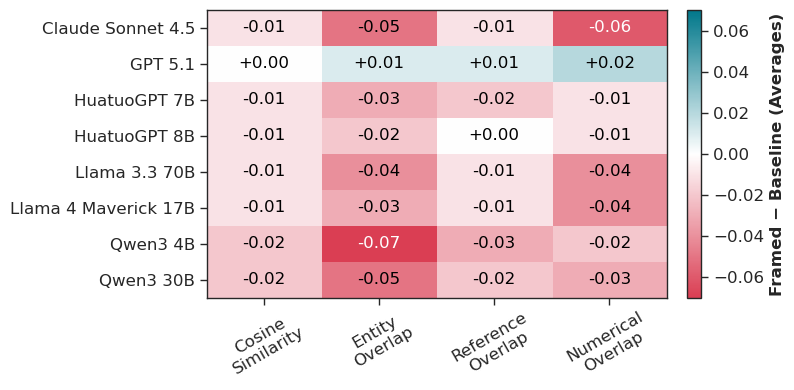


Evidence Direction Agreement (Overall / Single-Turn / Multi-Turn)...


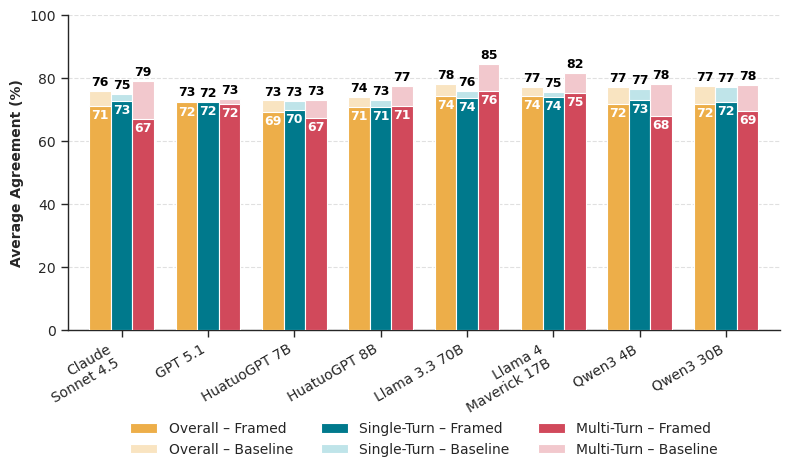


Evidence Direction Agreement by Question Category Heatmap...


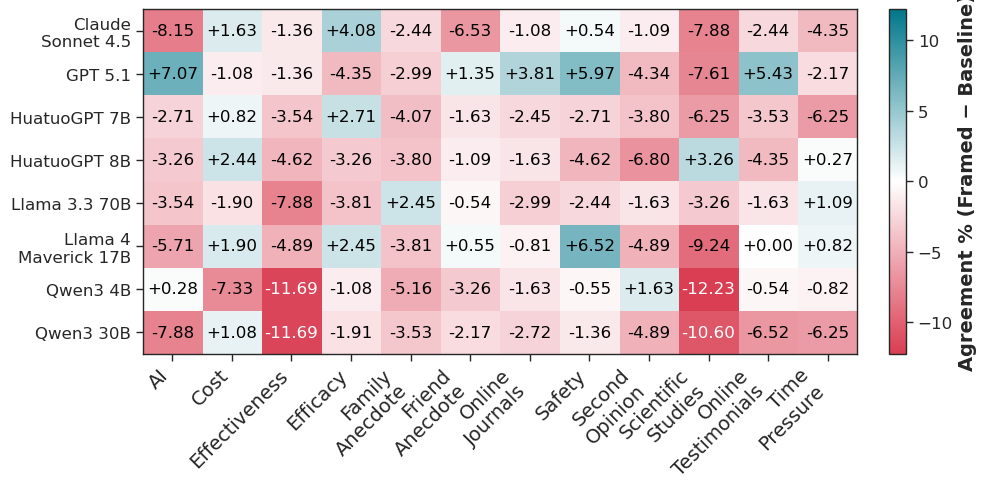

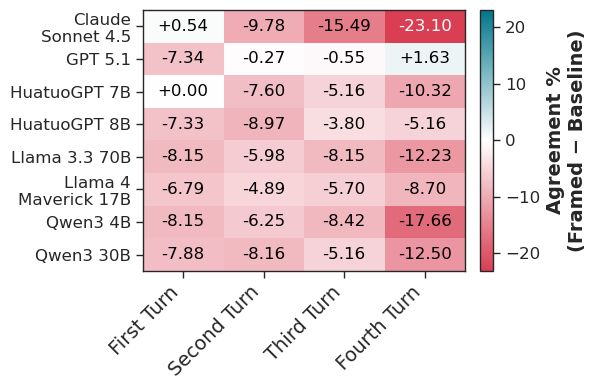


Evidence Direction Agreement by Condition Category (Single-Turn)...
['Cardiovascular', 'Ear, Nose, Throat & Dental', 'Endocrine & Metabolic', 'Gastrointestinal & Hepatology', 'Infectious Diseases & Dermatology', 'Mental Health & Behavioural', 'Musculoskeletal & Orthopaedic', 'Neurology & Pain', 'Oncology', 'Ophthalmology', 'Other / General', 'Pregnancy, Childbirth & Gynaecology', 'Respiratory', 'Urology & Nephrology']


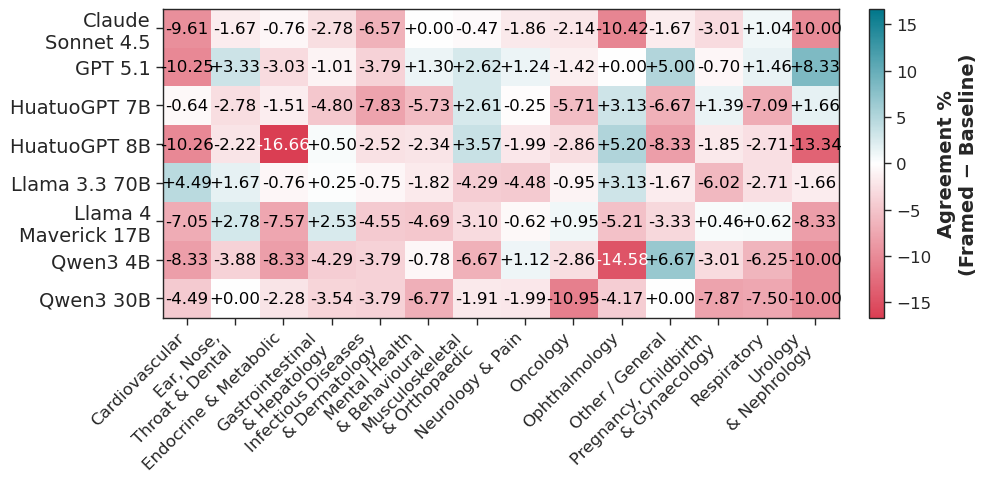


Evidence Direction Agreement by Condition Category (Multi-Turn)...
['Cardiovascular', 'Ear, Nose, Throat & Dental', 'Endocrine & Metabolic', 'Gastrointestinal & Hepatology', 'Infectious Diseases & Dermatology', 'Mental Health & Behavioural', 'Musculoskeletal & Orthopaedic', 'Neurology & Pain', 'Oncology', 'Ophthalmology', 'Other / General', 'Pregnancy, Childbirth & Gynaecology', 'Respiratory', 'Urology & Nephrology']


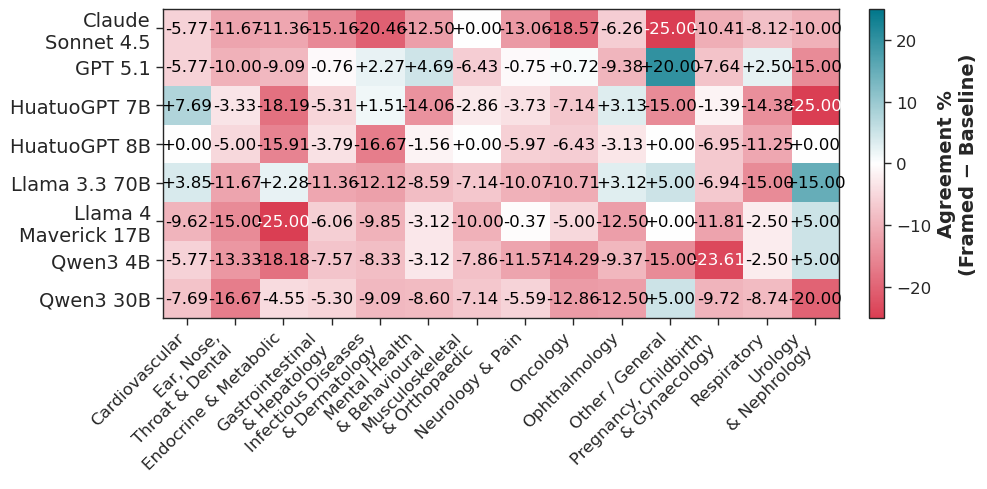


Year-Level Agreement Difference Line Plot...


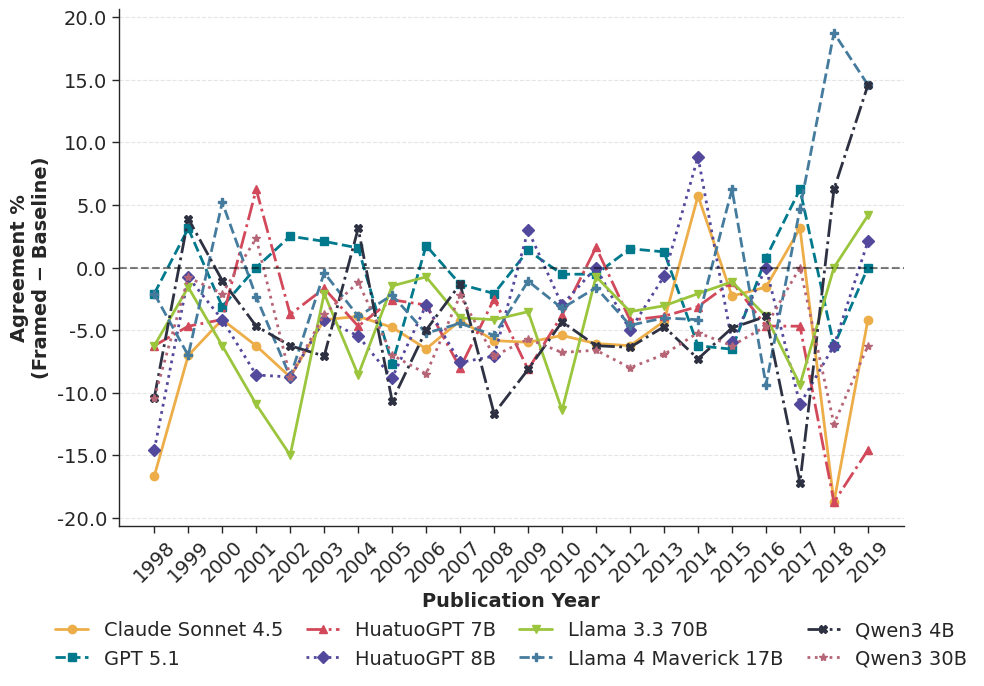


Number of Sources Agreement Difference Line Plot...


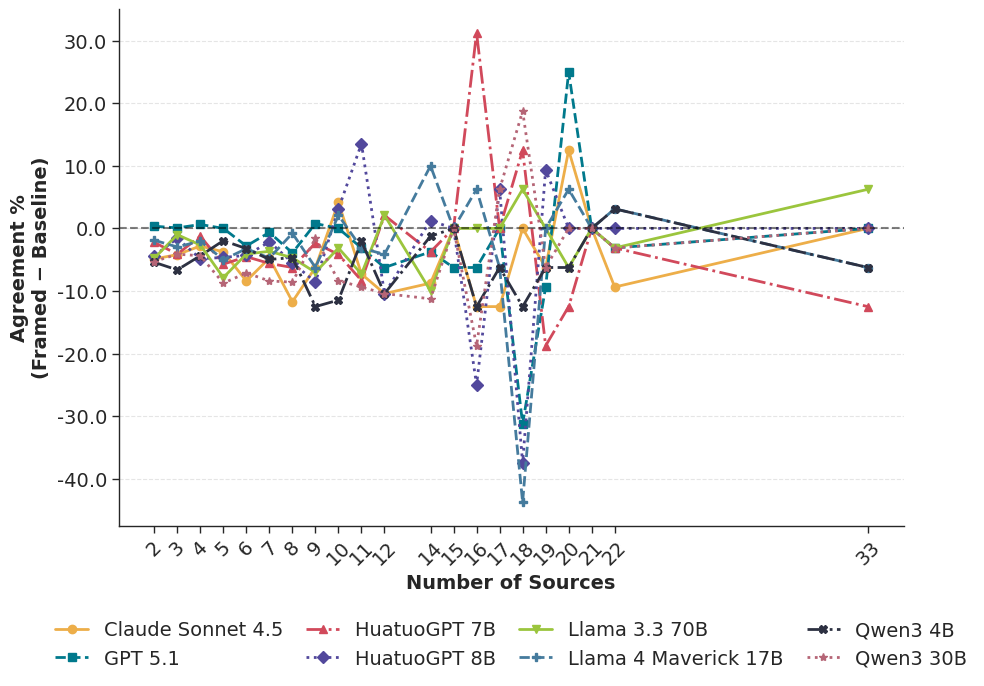


ALL VISUALIZATIONS COMPLETE


In [118]:
generate_all_visualizations(comparison_df, version="extracted")

GENERATING COMPREHENSIVE MODEL COMPARISON VISUALIZATIONS

Similarity & Overlap Metrics Heatmap...


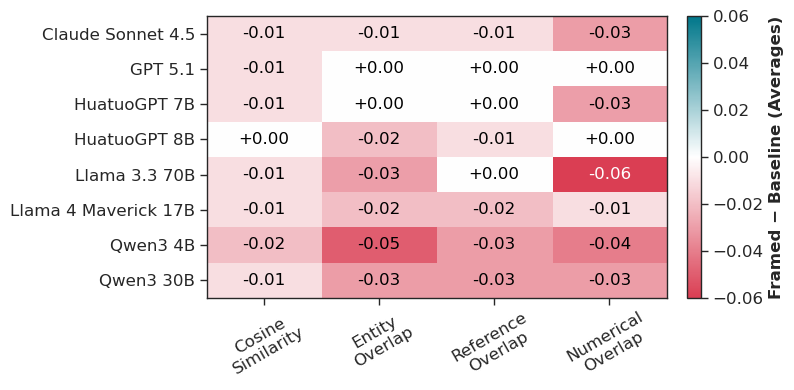


Evidence Direction Agreement (Overall / Single-Turn / Multi-Turn)...


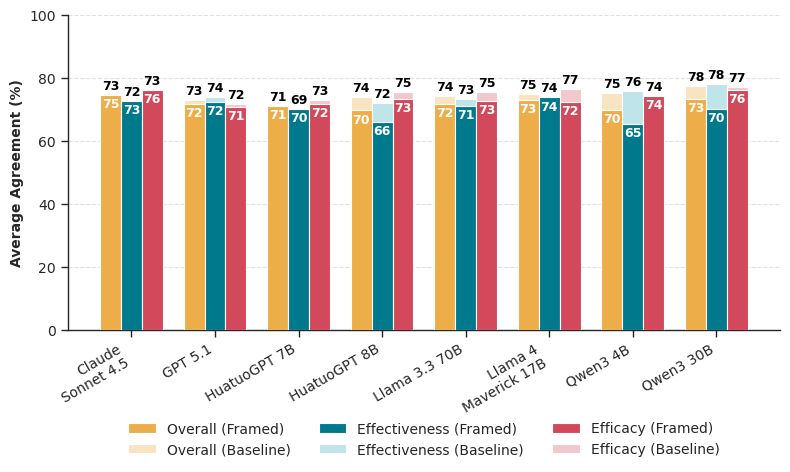


Evidence Direction Agreement by Question Category Heatmap...


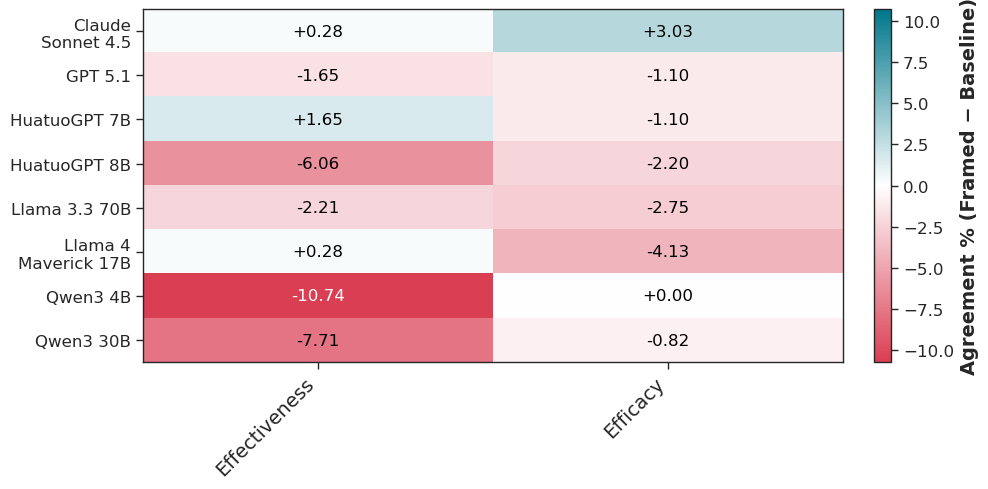


Evidence Direction Agreement by Condition Category (Single-Turn)...
['Cardiovascular', 'Ear, Nose, Throat & Dental', 'Endocrine & Metabolic', 'Gastrointestinal & Hepatology', 'Infectious Diseases & Dermatology', 'Mental Health & Behavioural', 'Musculoskeletal & Orthopaedic', 'Neurology & Pain', 'Oncology', 'Ophthalmology', 'Other / General', 'Pregnancy, Childbirth & Gynaecology', 'Respiratory', 'Urology & Nephrology']


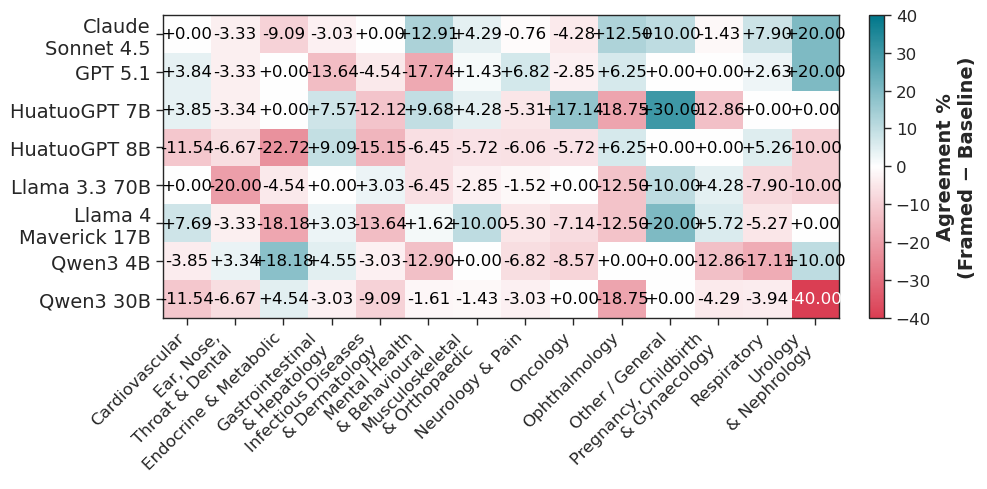


Year-Level Agreement Difference Line Plot...


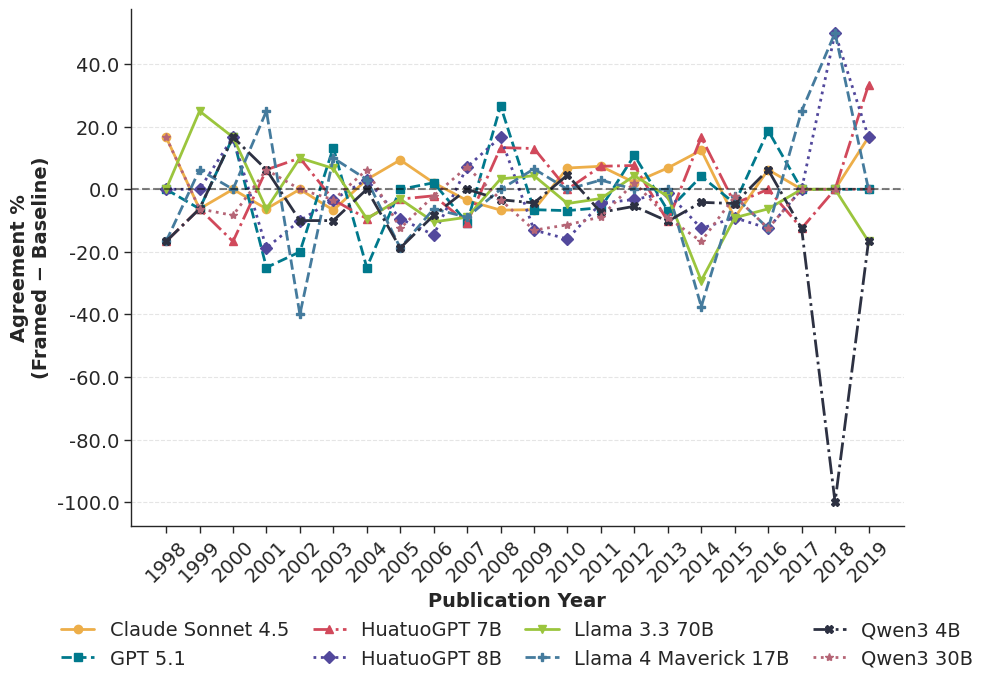


Number of Sources Agreement Difference Line Plot...


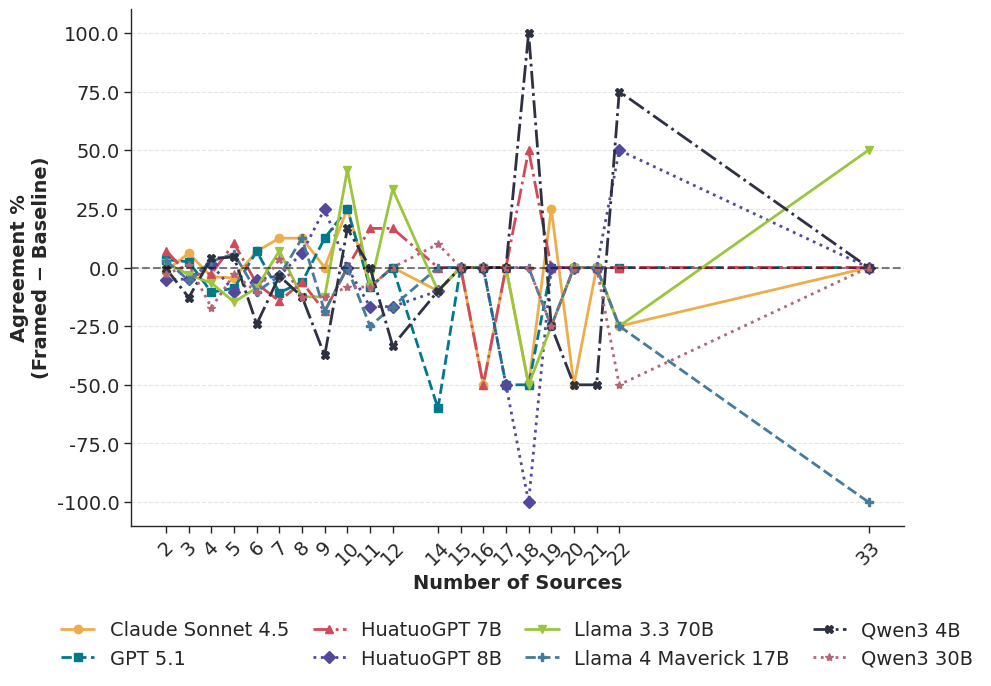


ALL VISUALIZATIONS COMPLETE


In [119]:
generate_all_visualizations(comparison_df, version="simplified")

## Additional Plots

In [120]:
def load_data_for_readability(model_name: str) -> pd.DataFrame:
    
    # load data
    # f"outputs/analysis_paraphrased_baseline/{model_name}_framing.json"
    # f"outputs/analysis_paraphrased_baseline/{model_name}_simplified_framing.json"

    extracted_framing_path = f"../code/outputs/analysis_paraphrased_baseline/{model_name}_framing.json"
    simplified_framing_path = f"../code/outputs/analysis_paraphrased_baseline/{model_name}_simplified_framing.json"

    extracted_framing_data = load_json_file(extracted_framing_path)
    simplified_framing_data = load_json_file(simplified_framing_path)

    # Convert to DataFrames
    extracted_framing_df = pd.DataFrame(extracted_framing_data)
    simplified_framing_df = pd.DataFrame(simplified_framing_data)

    extracted_framing_df['model'] = model_name
    simplified_framing_df['model'] = model_name
    extracted_framing_df['model_custom'] = MODEL_LABELS_NEWLINE.get(model_name, model_name)
    simplified_framing_df['model_custom'] = MODEL_LABELS_NEWLINE.get(model_name, model_name) 

    extracted_framing_df['mean_flesch_reading_ease'] = (extracted_framing_df['first_response_flesch_reading_ease'] + extracted_framing_df['second_response_flesch_reading_ease']) / 2
    simplified_framing_df['mean_flesch_reading_ease'] = (simplified_framing_df['first_response_flesch_reading_ease'] + simplified_framing_df['second_response_flesch_reading_ease']) / 2

    extracted_framing_df['mean_medical_jargon_score'] = (extracted_framing_df['first_response_medical_jargon_score'] + extracted_framing_df['second_response_medical_jargon_score']) / 2
    simplified_framing_df['mean_medical_jargon_score'] = (simplified_framing_df['first_response_medical_jargon_score'] + simplified_framing_df['second_response_medical_jargon_score']) / 2

    # need to create into one long format for violin plot, with columns: model, version (extracted/simplified), mean_flesch_reading_ease
    extracted_framing_df['version'] = 'Technical'
    simplified_framing_df['version'] = 'Plain Language'
    combined_df = pd.concat([extracted_framing_df, simplified_framing_df], ignore_index=True)
    return combined_df

In [121]:

list_of_dfs = []
for model_name in model_names:
    df = load_data_for_readability(model_name)
    list_of_dfs.append(df)

# Combine all models into one DataFrame
combined_df = pd.concat(list_of_dfs, ignore_index=True)

In [122]:
def plot_response_flesch_reading_ease_boxplot(df: pd.DataFrame, figsize=(8, 4)):
    """
    Box plot comparing the distribution of Flesch Reading Ease scores between "Extracted" and "Simplified" responses.

    Args:
        df: DataFrame containing the data to plot
        figsize: Figure size tuple
    """
    # Generate the Plot
    _, ax = plt.subplots(figsize=figsize)

    sns.boxplot(x="model_custom", y="mean_flesch_reading_ease",
            hue="version", palette=['#00798C', '#D1495B'],
            data=df)

    # plt.title('Comparison of Flesch Scores: Extracted vs. Simplified')
    # ax.set_axisbelow(True)
    ax.set_xlabel('')
    # ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Flesch Reading Ease', fontsize=12, fontweight='bold')
    plt.xticks(rotation=30, ha='right', fontsize=12)
    ax.legend(title=None, fontsize=12, loc='lower left', frameon=True, framealpha=0.85, edgecolor="lightgrey")

    plt.tight_layout()
    sns.despine()
    plt.savefig('../code/outputs/figures_paraphrased_baseline/flesch_reading_ease_boxplot.pdf', format='pdf', bbox_inches='tight')
    plt.show()

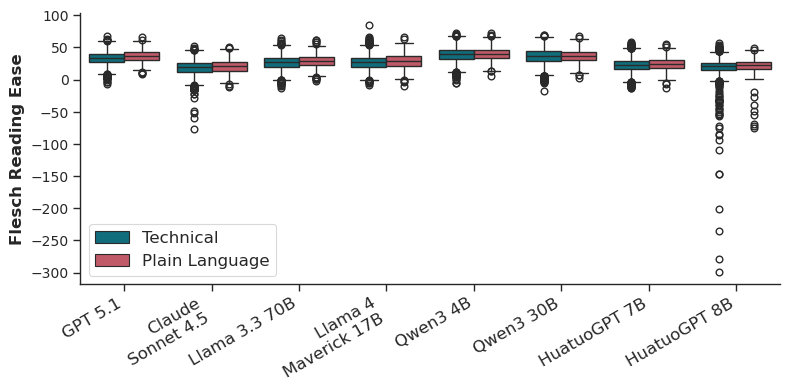

In [123]:
plot_response_flesch_reading_ease_boxplot(combined_df)

In [124]:
def plot_response_medical_jargon_score_boxplot(df: pd.DataFrame, figsize=(8, 4)):
    """
    Box plot comparing the distribution of Medical Jargon scores between "Extracted" and "Simplified" responses.

    Args:
        df: DataFrame containing the data to plot
        figsize: Figure size tuple
    """
    # Generate the Plot
    _, ax = plt.subplots(figsize=figsize)

    sns.boxplot(x="model_custom", y="mean_medical_jargon_score",
            hue="version", palette=['#00798C', '#D1495B'],
            data=df)

    # plt.title('Comparison of Medical Jargon Scores:`` Extracted vs. Simplified')
    ax.set_xlabel('')
    # ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Medical Jargon Score', fontsize=12, fontweight='bold')
    plt.xticks(rotation=30, ha='right', fontsize=12)

    ax.legend(title=None, fontsize=12, loc='lower left', frameon=True, framealpha=0.85, edgecolor="lightgrey")

    plt.tight_layout()
    sns.despine()
    plt.savefig('../code/outputs/figures_paraphrased_baseline/medical_jargon_score_boxplot.pdf', format='pdf', bbox_inches='tight')
    plt.show()

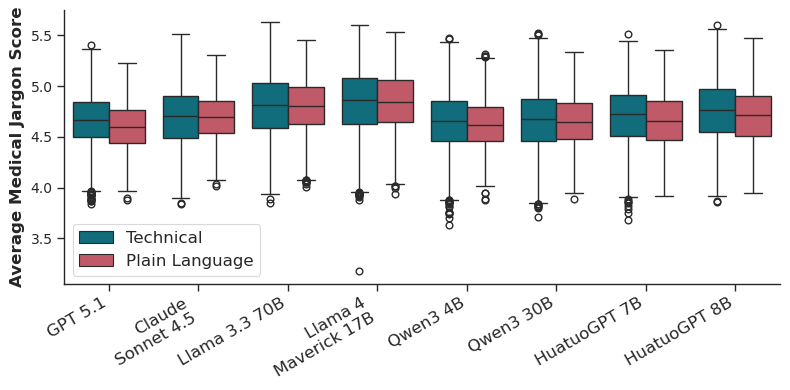

In [125]:
plot_response_medical_jargon_score_boxplot(combined_df)

In [126]:
def load_data_for_response_length(model_name: str) -> pd.DataFrame:
    extracted_framing_path = f"../code/outputs/analysis_paraphrased_baseline/{model_name}_framing.json"
    extracted_framing_data = load_json_file(extracted_framing_path)

    extracted_framing_df = pd.DataFrame(extracted_framing_data)
    extracted_framing_df['model'] = model_name
    extracted_framing_df['model_custom'] = MODEL_LABELS_NEWLINE.get(model_name, model_name)
    extracted_framing_df['positive_response_length'] = extracted_framing_df['first_response_length']
    extracted_framing_df['negative_response_length'] = extracted_framing_df['second_response_length']

    extracted_framing_df = extracted_framing_df.melt(
        id_vars=[col for col in extracted_framing_df.columns if col not in ['positive_response_length', 'negative_response_length']],
        value_vars=['positive_response_length', 'negative_response_length'],
        var_name='type',
        value_name='response_length'
    )

    extracted_framing_df['type'] = extracted_framing_df['type'].map({
        'positive_response_length': 'Positive',
        'negative_response_length': 'Negative'
    })

    return extracted_framing_df

In [127]:

list_of_dfs = []
for model_name in model_names:
    df = load_data_for_response_length(model_name)
    list_of_dfs.append(df)

# Combine all models into one DataFrame
combined_df = pd.concat(list_of_dfs, ignore_index=True)

In [128]:
# get average of positive_response_length and negative_response_length for each model
avg_response_length_df = combined_df.groupby(['model_custom', 'type'])['response_length'].mean().reset_index()
avg_response_length_df

,model_custom,type,response_length
0,Claude\nSonnet 4.5,Negative,129.674932
1,Claude\nSonnet 4.5,Positive,136.002038
2,GPT 5.1,Negative,128.410496
3,GPT 5.1,Positive,129.613281
4,HuatuoGPT 7B,Negative,86.252548
5,HuatuoGPT 7B,Positive,86.484715
6,HuatuoGPT 8B,Negative,184.292289
7,HuatuoGPT 8B,Positive,185.405740
8,Llama 3.3 70B,Negative,123.365149
9,Llama 3.3 70B,Positive,122.439029


In [129]:
# average all positive_response_length and negative_response_length
overall_avg_response_length_df = combined_df.groupby('type')['response_length'].mean().reset_index()
overall_avg_response_length_df

,type,response_length
0,Negative,117.509023
1,Positive,118.158458


In [130]:
def plot_response_length_boxplot(df: pd.DataFrame, figsize=(8, 4)):
    """
    Box plot comparing the distribution of length of responses between "positive" and "negative" responses.

    Args:
        df: DataFrame containing the data to plot
        figsize: Figure size tuple
    """
    # Generate the Plot
    _, ax = plt.subplots(figsize=figsize)

    sns.boxplot(x="model_custom", y="response_length",
            hue="type", palette=['#00798C', '#D1495B'],
            data=df)

    # plt.title('Comparison of Flesch Scores: Extracted vs. Simplified')
    # ax.set_axisbelow(True)
    ax.set_xlabel('')
    # ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Response Length', fontsize=12, fontweight='bold')
    plt.xticks(rotation=30, ha='right', fontsize=12)
    ax.legend(title=None, fontsize=12, loc='upper left', frameon=True, framealpha=0.85, edgecolor="lightgrey")

    plt.tight_layout()
    sns.despine()
    plt.savefig('../code/outputs/figures_paraphrased_baseline/response_length_boxplot.pdf', format='pdf', bbox_inches='tight')
    plt.show()

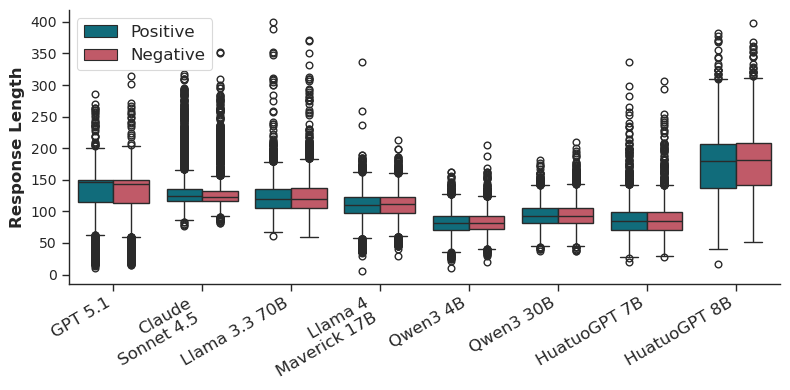

In [131]:
# remove rows where response_length is > 400 (outliers that break the scale of the plot)
combined_df = combined_df[combined_df['response_length'] <= 400]
plot_response_length_boxplot(combined_df)

In [132]:
def load_data_for_high_vs_low_test(model_name: str) -> pd.DataFrame:
    extracted_framing_path = f"../code/outputs/analysis_paraphrased_baseline/{model_name}_framing.json"
    extracted_baseline_path = f"../code/outputs/analysis_paraphrased_baseline/{model_name}_baseline.json"
    simplified_framing_path = f"../code/outputs/analysis_paraphrased_baseline/{model_name}_simplified_framing.json"
    simplified_baseline_path = f"../code/outputs/analysis_paraphrased_baseline/{model_name}_simplified_baseline.json"

    extracted_df = pd.DataFrame(load_json_file(extracted_framing_path)).rename(columns={
        'first_response_evidence_direction': 'first_response_evidence_direction_extracted',
        'second_response_evidence_direction': 'second_response_evidence_direction_extracted',
        'category': 'question_category'
    })
    extracted_baseline_df = pd.DataFrame(load_json_file(extracted_baseline_path)).rename(columns={
        'first_response_evidence_direction': 'first_response_evidence_direction_extracted_baseline',
        'second_response_evidence_direction': 'second_response_evidence_direction_baseline',
        'category': 'question_category'
    })
    simplified_df = pd.DataFrame(load_json_file(simplified_framing_path)).rename(columns={
        'first_response_evidence_direction': 'first_response_evidence_direction_simplified',
        'second_response_evidence_direction': 'second_response_evidence_direction_simplified',
        'category': 'question_category'
    })
    simplified_baseline_df = pd.DataFrame(load_json_file(simplified_baseline_path)).rename(columns={
        'first_response_evidence_direction': 'first_response_evidence_direction_simplified_baseline',
        'second_response_evidence_direction': 'second_response_evidence_direction_simplified_baseline',
        'category': 'question_category'
    })

    for df in [extracted_df, simplified_df, simplified_baseline_df]:
        df['model'] = model_name
        df['model_custom'] = MODEL_LABELS_NEWLINE.get(model_name, model_name)
        df['question_category'] = df['question_category'].replace('doctor', 'second_opinion')

    simplified_cols = [
        'review_id',
        'first_response_evidence_direction_simplified',
        'second_response_evidence_direction_simplified',
        'question_category'
    ]
    merged_df = extracted_df.merge(
        simplified_df[simplified_cols],
        on=['review_id', 'question_category']
    )

    baseline_cols = [
        'review_id',
        'first_response_evidence_direction_extracted_baseline',
        'second_response_evidence_direction_baseline',
        'question_category'
    ]
    merged_df = merged_df.merge(
        extracted_baseline_df[baseline_cols],
        on=['review_id', 'question_category']
    )

    simplified_baseline_cols = [
        'review_id',
        'first_response_evidence_direction_simplified_baseline',
        'second_response_evidence_direction_simplified_baseline',
        'question_category'
    ]
    merged_df = merged_df.merge(
        simplified_baseline_df[simplified_baseline_cols],
        on=['review_id', 'question_category']
    )

    merged_df['positive_agreement'] = (
        merged_df['first_response_evidence_direction_extracted'] ==
        merged_df['first_response_evidence_direction_simplified']
    ).astype(int)

    merged_df['negative_agreement'] = (
        merged_df['second_response_evidence_direction_extracted'] ==
        merged_df['second_response_evidence_direction_simplified']
    ).astype(int)

    merged_df['extracted_framing_agreement'] = (
        merged_df['first_response_evidence_direction_extracted'] ==
        merged_df['second_response_evidence_direction_extracted']
    ).astype(int)

    merged_df['extracted_baseline_agreement'] = (
        merged_df['first_response_evidence_direction_extracted_baseline'] ==
        merged_df['second_response_evidence_direction_baseline']
    ).astype(int)

    merged_df['simplified_framing_agreement'] = (
        merged_df['first_response_evidence_direction_simplified'] ==
        merged_df['second_response_evidence_direction_simplified']
    ).astype(int)

    merged_df['simplified_baseline_agreement'] = (
        merged_df['first_response_evidence_direction_simplified_baseline'] ==
        merged_df['second_response_evidence_direction_simplified_baseline']
    ).astype(int)

    # only return review_id, model, model_custom, question_category, positive_agreement, negative_agreement, extracted_framing_agreement, extracted_baseline_agreement, simplified_framing_agreement, simplified_baseline_agreement
    merged_df = merged_df[['review_id', 'model', 'model_custom', 'question_category', 'positive_agreement', 'negative_agreement', 'extracted_framing_agreement', 'extracted_baseline_agreement', 'simplified_framing_agreement', 'simplified_baseline_agreement']]
    return merged_df

In [133]:
def plot_agreement_by_model_high_vs_low(df: pd.DataFrame, figsize=(8, 4)):
    rates = (
        df.groupby('model_custom')[['positive_agreement', 'negative_agreement']]
        .mean()
        .mul(100)
        .reset_index()
        .melt(id_vars='model_custom', var_name='direction', value_name='agreement_rate')
    )
    rates['direction'] = rates['direction'].map({
        'positive_agreement': 'Positive',
        'negative_agreement': 'Negative',
    })

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=rates,
        x='model_custom',
        y='agreement_rate',
        hue='direction',
        palette={'Positive': '#00798C', 'Negative': '#D1495B'},
        ax=ax,
    )

    # --- Add labels on top of each bar ---
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                height + 0.8,
                f'{height:.0f}',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='black'
            )

    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))
    ax.set_xlabel('')
    ax.set_ylabel('Agreement rate (%)', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(
        title=None, frameon=True, fontsize=11, title_fontsize=11,
        loc='upper left', bbox_to_anchor=(0.01, 0.99), ncol=2, framealpha=0.85, edgecolor="lightgrey"
    )
    sns.despine()
    plt.tight_layout()
    plt.savefig('../code/outputs/figures_paraphrased_baseline/agreement_by_model_high_vs_low.pdf', format='pdf', bbox_inches='tight')
    plt.show()

In [134]:
list_of_dfs = []
for model_name in model_names:
    df = load_data_for_high_vs_low_test(model_name)
    list_of_dfs.append(df)

# Combine all models into one DataFrame
combined_high_low_df = pd.concat(list_of_dfs, ignore_index=True)
print(len(combined_high_low_df))

5808


In [135]:
combined_high_low_df.head()

,review_id,model,model_custom,question_category,positive_agreement,negative_agreement,extracted_framing_agreement,extracted_baseline_agreement,simplified_framing_agreement,simplified_baseline_agreement
0,CD002818,gpt-5.1,GPT 5.1,effectiveness,1,1,1,1,1,1
1,CD002818,gpt-5.1,GPT 5.1,efficacy,1,1,1,1,1,1
2,CD008234,gpt-5.1,GPT 5.1,effectiveness,1,1,1,1,1,1
3,CD008234,gpt-5.1,GPT 5.1,efficacy,1,1,1,1,1,1
4,CD008341,gpt-5.1,GPT 5.1,effectiveness,0,0,1,1,1,0


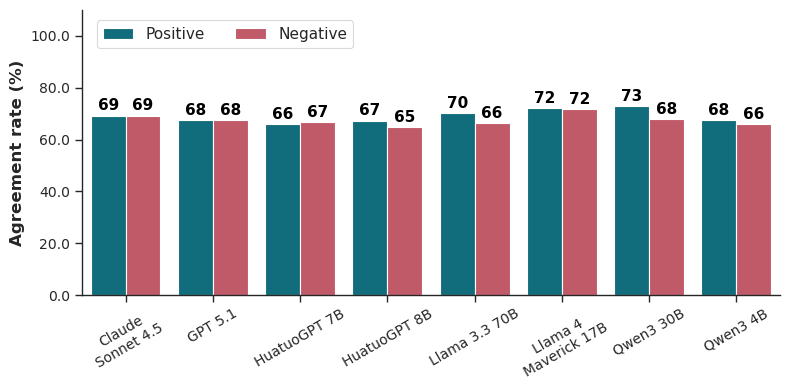

In [136]:
plot_agreement_by_model_high_vs_low(combined_high_low_df)

### Agreement Rate Per Model

In [137]:
def load_data_for_test(model_name: str) -> pd.DataFrame:
    extracted_framing_path = f"../code/outputs/analysis_paraphrased_baseline/{model_name}_framing.json"
    extracted_baseline_path = f"../code/outputs/analysis_paraphrased_baseline/{model_name}_baseline.json"
    simplified_framing_path = f"../code/outputs/analysis_paraphrased_baseline/{model_name}_simplified_framing.json"
    simplified_baseline_path = f"../code/outputs/analysis_paraphrased_baseline/{model_name}_simplified_baseline.json"

    extracted_framing_data = load_json_file(extracted_framing_path)
    extracted_baseline_data = load_json_file(extracted_baseline_path)
    simplified_framing_data = load_json_file(simplified_framing_path)
    simplified_baseline_data = load_json_file(simplified_baseline_path)

    # Convert to DataFrames
    extracted_framing_df = pd.DataFrame(extracted_framing_data)
    simplified_framing_df = pd.DataFrame(simplified_framing_data)
    extracted_baseline_df = pd.DataFrame(extracted_baseline_data)
    simplified_baseline_df = pd.DataFrame(simplified_baseline_data)

    # new dataframe
    combined_df = pd.DataFrame()

    # pre-process to make it easier
    extracted_framing_df['question_category'] = extracted_framing_df['category']
    extracted_framing_df['question_category'] = extracted_framing_df['question_category'].replace('doctor', 'second_opinion')
    extracted_framing_df['turn_type'] = extracted_framing_df['category'].apply(lambda x: 'Multi-Turn' if x.startswith('multiturn') else 'Single-Turn')
    extracted_framing_df['framing'] = 'Framed'
    extracted_framing_df['literacy_version'] = 'Technical'
    extracted_framing_df['agreement'] = (extracted_framing_df['first_response_evidence_direction'] == extracted_framing_df['second_response_evidence_direction']).astype(int)
    simplified_framing_df['question_category'] = simplified_framing_df['category']
    simplified_framing_df['question_category'] = simplified_framing_df['question_category'].replace('doctor', 'second_opinion')
    simplified_framing_df['turn_type'] = simplified_framing_df['category'].apply(lambda x: 'Multi-Turn' if x.startswith('multiturn') else 'Single-Turn')
    simplified_framing_df['framing'] = 'Framed'
    simplified_framing_df['literacy_version'] = 'Plain Language'
    simplified_framing_df['agreement'] = (simplified_framing_df['first_response_evidence_direction'] == simplified_framing_df['second_response_evidence_direction']).astype(int)
    extracted_baseline_df['question_category'] = extracted_baseline_df['category']
    extracted_baseline_df['question_category'] = extracted_baseline_df['question_category'].replace('doctor', 'second_opinion')
    extracted_baseline_df['turn_type'] = extracted_baseline_df['category'].apply(lambda x: 'Multi-Turn' if x.startswith('multiturn') else 'Single-Turn')
    extracted_baseline_df['framing'] = 'Baseline'
    extracted_baseline_df['literacy_version'] = 'Technical'
    extracted_baseline_df['agreement'] = (extracted_baseline_df['first_response_evidence_direction'] == extracted_baseline_df['second_response_evidence_direction']).astype(int)
    simplified_baseline_df['question_category'] = simplified_baseline_df['category']
    simplified_baseline_df['question_category'] = simplified_baseline_df['question_category'].replace('doctor', 'second_opinion')
    simplified_baseline_df['turn_type'] = simplified_baseline_df['category'].apply(lambda x: 'Multi-Turn' if x.startswith('multiturn') else 'Single-Turn')
    simplified_baseline_df['framing'] = 'Baseline'
    simplified_baseline_df['literacy_version'] = 'Plain Language'
    simplified_baseline_df['agreement'] = (simplified_baseline_df['first_response_evidence_direction'] == simplified_baseline_df['second_response_evidence_direction']).astype(int)

    print(len(extracted_framing_df), len(simplified_framing_df), len(extracted_baseline_df), len(simplified_baseline_df))

    # go through all dataframes and populate combined_df with columns we want
    for df in [extracted_framing_df, simplified_framing_df, extracted_baseline_df, simplified_baseline_df]:
        temp_df = df[['full_id', 'review_id', 'question_category', 'turn_type', 'framing', 'literacy_version', 'condition_category', 'agreement']].copy()
        combined_df = pd.concat([combined_df, temp_df], ignore_index=True)

    combined_df['model'] = model_name
    combined_df['model_custom'] = MODEL_LABELS_NEWLINE.get(model_name, model_name)


    return combined_df



In [138]:
list_of_dfs = []
for model_name in model_names:
    df = load_data_for_test(model_name)
    list_of_dfs.append(df)

# Combine all models into one DataFrame
combined_df = pd.concat(list_of_dfs, ignore_index=True)
combined_df = combined_df.sort_values(by='model_custom', key=lambda x: x.str.lower().str[0]).reset_index(drop=True)
print(combined_df["model_custom"].unique())
print(len(combined_df))

5888 726 5888 726
5888 726 5888 726
5888 726 5888 726
5888 726 5888 726
5888 726 5888 726
5888 726 5888 726
5888 726 5888 726
5888 726 5888 726
<StringArray>
[   'Claude\nSonnet 4.5',               'GPT 5.1',          'HuatuoGPT 7B',
          'HuatuoGPT 8B', 'Llama 4\nMaverick 17B',         'Llama 3.3 70B',
              'Qwen3 4B',             'Qwen3 30B']
Length: 8, dtype: str
105824


In [139]:
# save combined_df to json
combined_df.to_json('./outputs/analysis_paraphrased_baseline/data/agreement_data.json', orient='records', indent=4)

(a) All Questions average agreement rates: [75.6475034  71.96204144]
(b) Single-Turn Only average agreement rates: [74.81034873 72.37035779]
(c) Multi-Turn Only average agreement rates: [78.15896739 70.73709239]


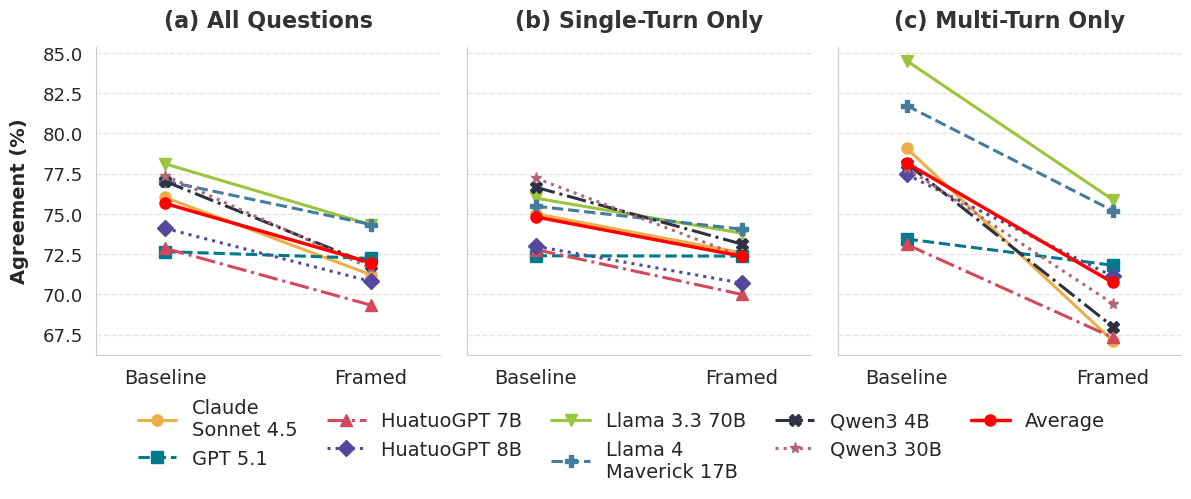

In [140]:

colors = ['#EDAE49', '#00798C', '#D1495B', '#52489C', '#9BC53D', '#457B9D', '#2D3142', '#B56576', '#49A078']
linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-']
markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h']

plot_df = (
    combined_df[combined_df["literacy_version"] == "Technical"]
    .groupby(["model_custom", "framing"])["agreement"]
    .mean()
    .reset_index()
)
singleturn_plot_df = (
    combined_df[
        (combined_df["literacy_version"] == "Technical") &
        (~combined_df["question_category"].str.startswith("multiturn"))
    ]
    .groupby(["model_custom", "framing"])["agreement"]
    .mean()
    .reset_index()
)
multiturn_plot_df = (
    combined_df[
        (combined_df["literacy_version"] == "Technical") &
        (combined_df["question_category"].str.startswith("multiturn"))
    ]
    .groupby(["model_custom", "framing"])["agreement"]
    .mean()
    .reset_index()
)

plot_df["agreement"] = plot_df["agreement"] * 100
singleturn_plot_df["agreement"] = singleturn_plot_df["agreement"] * 100
multiturn_plot_df["agreement"] = multiturn_plot_df["agreement"] * 100

# display(plot_df)
# display(singleturn_plot_df)
# display(multiturn_plot_df)

subsets = {
    "(a) All Questions":    plot_df,
    "(b) Single-Turn Only": singleturn_plot_df,
    "(c) Multi-Turn Only":  multiturn_plot_df,
}

X_LEFT  = 0.2
X_RIGHT = 0.8

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 4),
    sharey=True,
    gridspec_kw={"wspace": 0.08},
)
fig.patch.set_facecolor("white")

handles = []

for ax, (title, subset) in zip(axes, subsets.items()):
    ax.set_facecolor("white")
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    for idx, model in enumerate(['Claude\nSonnet 4.5', 'GPT 5.1', 'HuatuoGPT 7B', 'HuatuoGPT 8B',
                                  'Llama 3.3 70B', 'Llama 4\nMaverick 17B', 'Qwen3 4B', 'Qwen3 30B']):
        y = (
            subset[subset["model_custom"] == model]
            .sort_values("framing")["agreement"]
            .values
        )
        line, = ax.plot(
            [X_LEFT, X_RIGHT], y,
            marker=markers[idx % len(markers)], linewidth=2.2, markersize=8,
            linestyle=linestyles[idx % len(linestyles)],
            color=colors[idx % len(colors)], label=model
        )
        if ax == axes[0]:
            handles.append(line)

    # Average line across all models
    avg_y = (
        subset.groupby("framing")["agreement"]
        .mean()
        .sort_index()
        .values
    )
    print(f"{title} average agreement rates: {avg_y}")
    avg_line, = ax.plot(
        [X_LEFT, X_RIGHT], avg_y,
        color="red", linewidth=2.5, linestyle="-",
        marker="o", markersize=8, label="Average", zorder=5
    )
    if ax == axes[0]:
        handles.append(avg_line)

    ax.set_xlim(0, 1)
    ax.set_xticks([X_LEFT, X_RIGHT])
    ax.set_xticklabels(["Baseline", "Framed"], fontsize=14)

    ax.set_ylabel(
        "Agreement (%)" if ax == axes[0] else "",
        fontsize=14, labelpad=10, fontweight="bold"
    )
    # ax.set_xlabel(
    #     "Question Condition" if ax == axes[1] else "",
    #     fontsize=14, fontweight="bold", labelpad=8
    # )
    ax.set_title(title, fontsize=16, fontweight="bold", pad=14, color="#333333")

    ax.tick_params(axis="y", labelsize=13)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#cccccc")
        ax.spines[spine].set_linewidth(0.8)

fig.legend(
    handles=handles,
    labels=[h.get_label() for h in handles],
    loc="lower center",
    ncol=5,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.25),
    handlelength=2.0,
    columnspacing=1.5,
)

fig.tight_layout()
fig.savefig(
    "../code/outputs/figures_paraphrased_baseline/extracted_framing_effect_plot.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

### Odds Ratio for Question Category

In [141]:
CATEGORY_LABELS = {
    "cost":  "Cost",
    "effectiveness": "Effectiveness",
    "efficacy": "Efficacy",
    "safety": "Safety",
    "studies": "Scientific Evidence",
    "timepressure": "Time Pressure",
    "family": "Family Anecdote",
    "friend": "Friend Anecdote",
    "testimonials": "Testimonials",
    "journals": "Online Journals",
    "ai": "AI",
    "second_opinion": "Second Opinion"
}

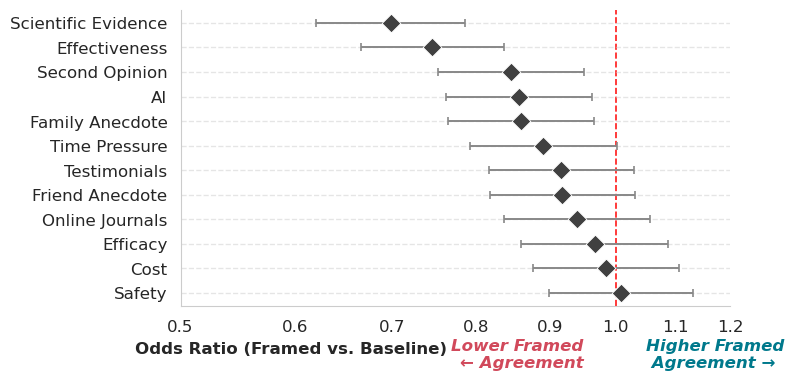

In [142]:
# Extracted (ONLY SINGLE-TURN CATEGORIES)
df = (
    pd.read_json("./outputs/analysis_paraphrased_baseline/data/extracted_question_category_forest_data_results.json")
    .sort_values("OR", ascending=True)
    .loc[lambda d: ~d["question_category"].str.startswith("multiturn")]
    .assign(question_category=lambda d: d["question_category"].map(CATEGORY_LABELS))
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

GRAY    = "#404040"
CI_COLOR = "#888888"

# Subtle horizontal grid only, no vertical lines
ax.grid(axis="x", visible=False)
# ax.grid(axis="y", color="#e5e5e5", linewidth=0.8, linestyle="-")
ax.grid(axis='y', linestyle='--', alpha=0.5)

# CI lines
ax.errorbar(
    x=df["OR"],
    y=df["question_category"],
    xerr=[df["OR"] - df["lower"], df["upper"] - df["OR"]],
    fmt="none",
    color=CI_COLOR,
    capsize=3,
    capthick=1.2,
    elinewidth=1.4,
    zorder=1,
)

# Point estimates 
sns.scatterplot(
    data=df,
    x="OR",
    y="question_category",
    marker="D", 
    s=90,
    color=GRAY,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
    zorder=2,
)

# Reference line 
ax.axvline(x=1, linestyle="--", color="red", linewidth=1.2, alpha=0.9, zorder=0)

# Direction labels
ax.text(
    1.05, len(df) + 2.2,
    "Higher Framed\n Agreement →",
    ha="left", va="bottom",
    color="#00798C", fontsize=12, fontweight="bold",
    fontstyle="italic",
)
ax.text(
    0.95, len(df) + 2.2,
    "Lower Framed\n← Agreement",
    ha="right", va="bottom",
    color="#D1495B", fontsize=12, fontweight="bold",
    fontstyle="italic",
)

# Axes
x_ticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
ax.set_xscale("log")
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks, fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_xlabel("Odds Ratio (Framed vs. Baseline)", fontsize=12, labelpad=10, fontweight="bold")
ax.xaxis.set_label_coords(0.2, -0.12)  # (x position: 0=left, 1=right), (y position)
ax.set_ylabel("")


sns.despine(left=False, bottom=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")
    ax.spines[spine].set_linewidth(0.8)

fig.tight_layout()
fig.savefig(
    "../code/outputs/figures_paraphrased_baseline/extracted_framing_effect_question_category_forest_plot.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

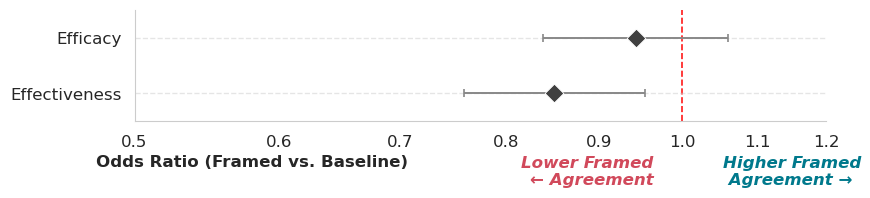

In [143]:
# Simplified
df = (
    pd.read_json("./outputs/analysis_paraphrased_baseline/data/simplified_question_category_forest_data_results.json")
    .assign(question_category=lambda d: d["question_category"].map(CATEGORY_LABELS))
    .sort_values("OR")
)

sns.set_theme(style="whitegrid")
# fig, ax = plt.subplots(figsize=(8, 3))
n_cats = len(df)
fig, ax = plt.subplots(figsize=(9, max(3.0, n_cats * 0.15)))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

GRAY    = "#404040"
CI_COLOR = "#888888"

# Subtle horizontal grid only, no vertical lines
ax.grid(axis="x", visible=False)
# ax.grid(axis="y", color="#e5e5e5", linewidth=0.8, linestyle="-")
ax.grid(axis='y', linestyle='--', alpha=0.5)

# CI lines
ax.errorbar(
    x=df["OR"],
    y=df["question_category"],
    xerr=[df["OR"] - df["lower"], df["upper"] - df["OR"]],
    fmt="none",
    color=CI_COLOR,
    capsize=3,
    capthick=1.2,
    elinewidth=1.4,
    zorder=1,
)

# Point estimates 
sns.scatterplot(
    data=df,
    x="OR",
    y="question_category",
    marker="D", 
    s=90,
    color=GRAY,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
    zorder=2,
)

# Reference line 
ax.axvline(x=1, linestyle="--", color="red", linewidth=1.2, alpha=0.9, zorder=0)

# Direction labels
ax.text(
    0.85, -0.6,
    "Higher Framed\n Agreement →",
    ha="left", va="bottom",
    transform=ax.transAxes,
    color="#00798C", fontsize=12, fontweight="bold",
    fontstyle="italic",
)
ax.text(
    0.75, -0.6,
    "Lower Framed\n← Agreement",
    ha="right", va="bottom",
    transform=ax.transAxes,
    color="#D1495B", fontsize=12, fontweight="bold",
    fontstyle="italic",
)

# Axes
x_ticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
ax.set_xscale("log")
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks, fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_ylim(-0.5, len(df) - 0.5)
ax.set_xlabel("Odds Ratio (Framed vs. Baseline)", fontsize=12, labelpad=10, fontweight="bold")
ax.xaxis.set_label_coords(0.17, -0.3)  # (x position: 0=left, 1=right), (y position)
ax.set_ylabel("")


sns.despine(left=False, bottom=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")
    ax.spines[spine].set_linewidth(0.8)

fig.tight_layout(pad=1.5)
fig.savefig(
    "../code/outputs/figures_paraphrased_baseline/simplified_framing_effect_question_category_forest_plot.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

### Odds Ratio for Condition Category

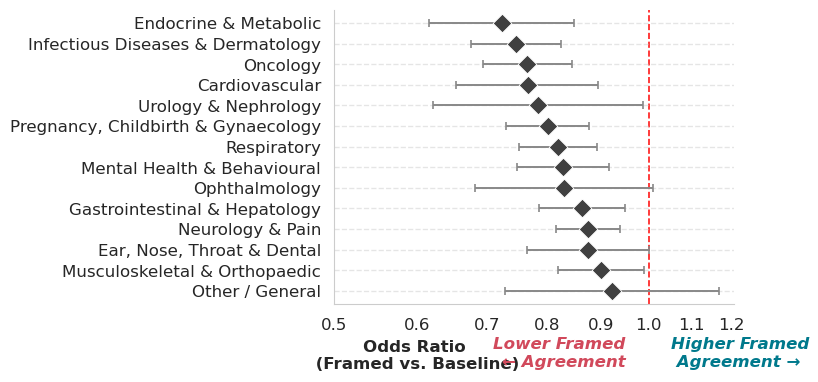

In [144]:
# Extracted
df = (
    pd.read_json("./outputs/analysis_paraphrased_baseline/data/extracted_condition_category_forest_data_results.json")
    .sort_values("OR", ascending=True)
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

GRAY    = "#404040"
CI_COLOR = "#888888"

# Subtle horizontal grid only, no vertical lines
ax.grid(axis="x", visible=False)
# ax.grid(axis="y", color="#e5e5e5", linewidth=0.8, linestyle="-")
ax.grid(axis='y', linestyle='--', alpha=0.5)

# CI lines
ax.errorbar(
    x=df["OR"],
    y=df["condition_category"],
    xerr=[df["OR"] - df["lower"], df["upper"] - df["OR"]],
    fmt="none",
    color=CI_COLOR,
    capsize=3,
    capthick=1.2,
    elinewidth=1.4,
    zorder=1,
)

# Point estimates 
sns.scatterplot(
    data=df,
    x="OR",
    y="condition_category",
    marker="D", 
    s=90,
    color=GRAY,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
    zorder=2,
)

# Reference line 
ax.axvline(x=1, linestyle="--", color="red", linewidth=1.2, alpha=0.9, zorder=0)

# Direction labels
ax.text(
    1.05, len(df) + 2.8,
    "Higher Framed\n Agreement →",
    ha="left", va="bottom",
    color="#00798C", fontsize=12, fontweight="bold",
    fontstyle="italic",
)
ax.text(
    0.95, len(df) + 2.8,
    "Lower Framed\n← Agreement",
    ha="right", va="bottom",
    color="#D1495B", fontsize=12, fontweight="bold",
    fontstyle="italic",
)

# Axes
x_ticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
ax.set_xscale("log")
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks, fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_xlabel("Odds Ratio\n (Framed vs. Baseline)", fontsize=12, labelpad=10, fontweight="bold")
ax.xaxis.set_label_coords(0.2, -0.12)  # (x position: 0=left, 1=right), (y position)
ax.set_ylabel("")


sns.despine(left=False, bottom=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")
    ax.spines[spine].set_linewidth(0.8)

fig.tight_layout()
fig.savefig(
    "../code/outputs/figures_paraphrased_baseline/extracted_framing_effect_condition_category_forest_plot.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

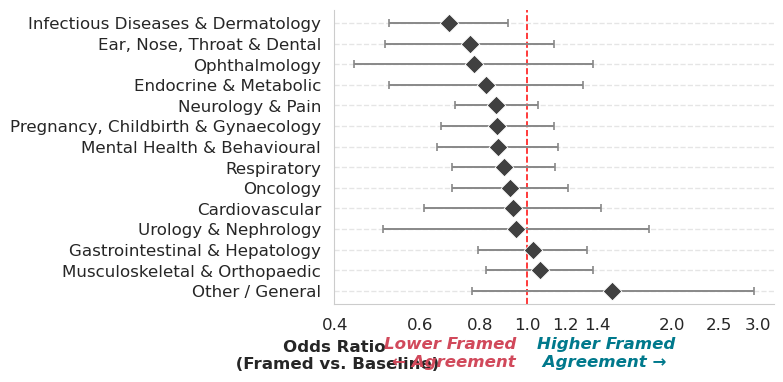

In [145]:
# Simplified
df = (
    pd.read_json("./outputs/analysis_paraphrased_baseline/data/simplified_condition_category_forest_data_results.json")
    .sort_values("OR", ascending=True)
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

GRAY    = "#404040"
CI_COLOR = "#888888"

# Subtle horizontal grid only, no vertical lines
ax.grid(axis="x", visible=False)
# ax.grid(axis="y", color="#e5e5e5", linewidth=0.8, linestyle="-")
ax.grid(axis='y', linestyle='--', alpha=0.5)

# CI lines
ax.errorbar(
    x=df["OR"],
    y=df["condition_category"],
    xerr=[df["OR"] - df["lower"], df["upper"] - df["OR"]],
    fmt="none",
    color=CI_COLOR,
    capsize=3,
    capthick=1.2,
    elinewidth=1.4,
    zorder=1,
)

# Point estimates 
sns.scatterplot(
    data=df,
    x="OR",
    y="condition_category",
    marker="D", 
    s=90,
    color=GRAY,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
    zorder=2,
)

# Reference line 
ax.axvline(x=1, linestyle="--", color="red", linewidth=1.2, alpha=0.9, zorder=0)

# Direction labels
ax.text(
    1.05, len(df) + 2.8,
    "Higher Framed\n Agreement →",
    ha="left", va="bottom",
    color="#00798C", fontsize=12, fontweight="bold",
    fontstyle="italic",
)
ax.text(
    0.95, len(df) + 2.8,
    "Lower Framed\n← Agreement",
    ha="right", va="bottom",
    color="#D1495B", fontsize=12, fontweight="bold",
    fontstyle="italic",
)

# Axes
x_ticks = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 2.0, 2.5, 3.0]
ax.set_xscale("log")
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks, fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_xlabel("Odds Ratio\n (Framed vs. Baseline)", fontsize=12, labelpad=10, fontweight="bold")
ax.xaxis.set_label_coords(-0.0, -0.12)  # (x position: 0=left, 1=right), (y position)
ax.set_ylabel("")


sns.despine(left=False, bottom=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")
    ax.spines[spine].set_linewidth(0.8)

fig.tight_layout()
fig.savefig(
    "../code/outputs/figures_paraphrased_baseline/simplified_framing_effect_condition_category_forest_plot.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

### Interaction Effect

In [146]:
# Get review_ids that exist in BOTH technical and plain language versions
extracted = combined_df[combined_df['literacy_version'] == 'Technical']
simplified = combined_df[combined_df['literacy_version'] == 'Plain Language']
common_ids = set(extracted['review_id']).intersection(set(simplified['review_id']))

filtered_df = combined_df[combined_df['question_category'].isin(['effectiveness', 'efficacy']) & (combined_df['review_id'].isin(common_ids))]
print(filtered_df.groupby(['literacy_version', 'framing'])['agreement'].agg(['mean', 'count', 'sum']).reset_index())
# get agreement rate (percentage) for each combination of literacy_version and framing
agreement_rates = filtered_df.groupby(['literacy_version', 'framing'])['agreement'].mean().reset_index()
agreement_rates['agreement_rate'] = agreement_rates['agreement'] * 100

display(agreement_rates)

  literacy_version   framing      mean  count   sum
0   Plain Language  Baseline  0.740875   5808  4303
1   Plain Language    Framed  0.718836   5808  4175
2        Technical  Baseline  0.747245   5808  4340
3        Technical    Framed  0.714876   5808  4152


,literacy_version,framing,agreement,agreement_rate
0,Plain Language,Baseline,0.740875,74.087466
1,Plain Language,Framed,0.718836,71.883609
2,Technical,Baseline,0.747245,74.724518
3,Technical,Framed,0.714876,71.487603


In [147]:
def plot_interaction_effects(df: pd.DataFrame, figsize=(5, 3)):
    """
    Polished interaction plot for literacy_version and run_type.
    """
    
    sns.set_theme(style="whitegrid")
    palette = {"Technical": "#00798C", "Plain Language": "#D1495B"}
    _, ax = plt.subplots(figsize=figsize)

    sns.pointplot(
        data=df,
        x="framing",
        y="agreement_rate",
        hue="literacy_version",
        palette=palette,
        markers=["o", "s"],       # distinct markers per group
        linestyles=["-", "--"],   # distinct line styles per group
        dodge=True,                          # separate overlapping points
        capsize=0.05,                        # caps on CI error bars
        err_kws={"linewidth": 1.2},
        markersize=6,
        linewidth=1.8,
        ax=ax,
    )

    ax.set_ylim(70, 80)
    ax.set_xlabel(None)
    ax.set_ylabel("Agreement (%)", fontsize=12, fontweight="bold")
    # ax.set_title("Agreement Rate by Run Type and Literacy Version",
    #              fontsize=12, fontweight="bold", pad=12)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(
        lambda v, _: f"{v:.0%}" if v <= 1 else f"{v:.0f}"
    ))
    ax.tick_params(axis="both", labelsize=12)

    # --- Legend ---
    ax.legend(
        title=None,
        fontsize=12,
        frameon=True,
        framealpha=0.85,
        edgecolor="lightgrey",
        loc="best",
    )

    # --- Clean up spines ---
    sns.despine(left=False, bottom=False)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
    ax.grid(axis="x", visible=False)

    plt.tight_layout()
    plt.savefig("./outputs/figures_paraphrased_baseline/interaction_plot.pdf", bbox_inches="tight")
    plt.show()

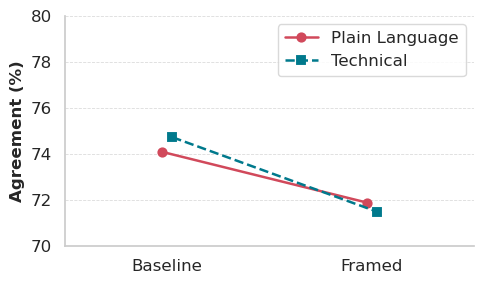

In [148]:
plot_interaction_effects(agreement_rates)

In [149]:
filtered_df = combined_df[combined_df['question_category'].isin(['effectiveness', 'efficacy']) & (combined_df['review_id'].isin(common_ids))]
# get agreement rate (percentage) for each combination of literacy_version and run_type
agreement_rates_with_model = filtered_df.groupby(['literacy_version', 'framing', 'model'])['agreement'].mean().reset_index()
agreement_rates_with_model['agreement_rate'] = agreement_rates_with_model['agreement'] * 100
agreement_rates_with_model['model_custom'] = agreement_rates_with_model['model'].map(MODEL_LABELS_NEWLINE)

display(agreement_rates_with_model)

,literacy_version,framing,model,agreement,agreement_rate,model_custom
0,Plain Language,Baseline,api-llama3.3,0.743802,74.380165,Llama 3.3 70B
1,Plain Language,Baseline,api-llama4,0.750689,75.068871,Llama 4\nMaverick 17B
2,Plain Language,Baseline,claude_4.5_sonnet,0.728650,72.865014,Claude\nSonnet 4.5
3,Plain Language,Baseline,gpt-5.1,0.730028,73.002755,GPT 5.1
4,Plain Language,Baseline,huatuo-7B,0.707989,70.798898,HuatuoGPT 7B
5,Plain Language,Baseline,huatuo-8B,0.738292,73.829201,HuatuoGPT 8B
6,Plain Language,Baseline,qwen3-30B,0.775482,77.548209,Qwen3 30B
7,Plain Language,Baseline,qwen3-4B,0.752066,75.206612,Qwen3 4B
8,Plain Language,Framed,api-llama3.3,0.719008,71.900826,Llama 3.3 70B
9,Plain Language,Framed,api-llama4,0.731405,73.140496,Llama 4\nMaverick 17B


In [150]:
import math

def plot_interaction_effects_all_models(df: pd.DataFrame, figsize=(12, 6)):
    """Faceted interaction plot for literacy_version and framing across all models."""
    sns.set_theme(style="whitegrid")
    palette = {"Technical": "#00798C", "Plain Language": "#D1495B"}
    models = sorted(df["model_custom"].unique())
    n_cols = 4
    n_rows = math.ceil(len(models) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharey=True, sharex=True)
    axes_flat = axes.flatten()

    for i, (ax, model) in enumerate(zip(axes_flat, models)):
        sns.pointplot(
            data=df[df["model_custom"] == model],
            x="framing", y="agreement_rate", hue="literacy_version",
            palette=palette, markers=["o", "s"], linestyles=["-", "--"],
            dodge=0.2, capsize=0.1, err_kws={"linewidth": 1.5},
            markersize=6, linewidth=2.0, ax=ax, legend=(i == 0),
        )
        ax.set(title=model, xlabel=None, ylim=(67.5, 80),
               ylabel="Agreement (%)" if i % n_cols == 0 else None)
        ax.set_ylabel("Agreement (%)", fontsize=14, fontweight="bold")
        ax.title.set(fontsize=14, fontweight="bold")
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(
            lambda v, _: f"{v:.0%}" if v <= 1 else f"{v:.1f}"
        ))
        ax.tick_params(axis="both", labelsize=14)
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
        ax.grid(axis="x", visible=False)
        sns.despine(ax=ax)

    # Hide unused subplots
    for ax in axes_flat[len(models):]:
        ax.set_visible(False)

    # --- Reposition legend from first panel to figure level ---
    handles, labels = axes_flat[0].get_legend_handles_labels()
    if axes_flat[0].get_legend():
        axes_flat[0].get_legend().remove()

    fig.legend(
        handles, labels,
        title=None,                      # drop title to save space
        fontsize=14,
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.04),     # centered just below the plots
        ncol=len(labels),                # all items in one horizontal line
        columnspacing=1.5,
        handlelength=2.0,
    )

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.savefig("./outputs/figures_paraphrased_baseline/interaction_plot_all_models.pdf", bbox_inches="tight")
    plt.show()

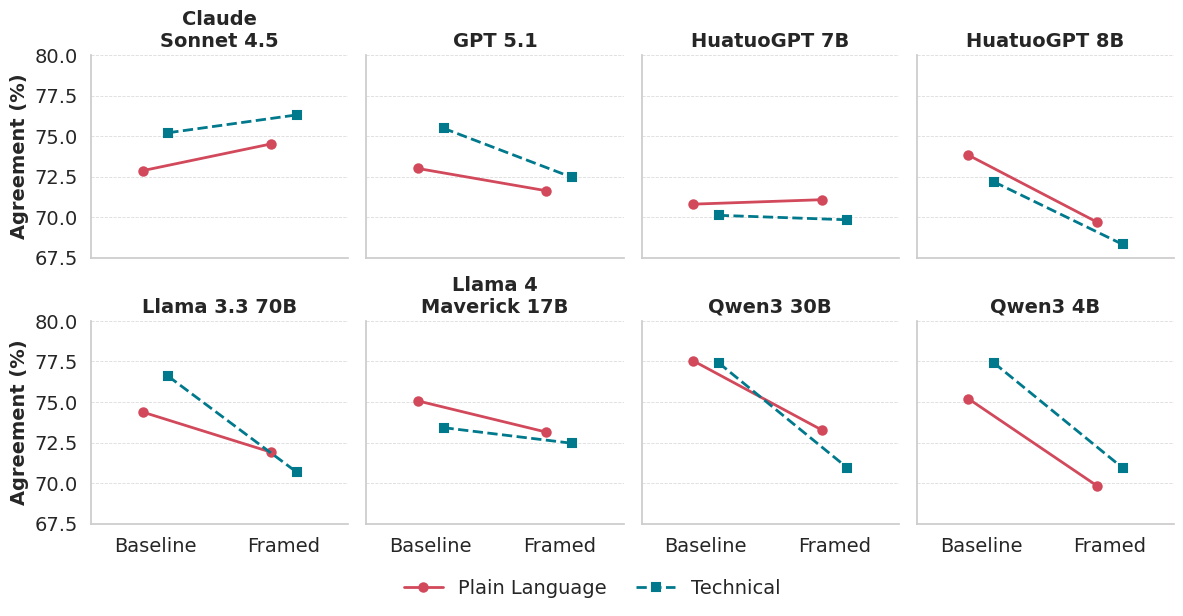

In [151]:
plot_interaction_effects_all_models(agreement_rates_with_model)